# Notebook 2: Studying chaotic behaviour in in elementary cellular automata

Purpose of this notebook is to give an insight into how elementary cellular automata evolve over time, with their respective rules that give place to chaotic behaviors.

Firstly, import all relevant functions from notebook "Elementary CA.ipynb"

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [51]:
from Functions_for_Notebook_1 import make_rule, make_rule_zero_condition, make_rule_symmetry #For making the rules

from Functions_for_Notebook_1 import dynamics, dynamics_reflection, dynamics_periodic #For the dynamics

from Functions_for_Notebook_1 import plot_grid #For the plotting

In this notebook we study the evolution of systems, particularly lookiong for chaotic cellular automata and ways to classify this chaos. A through literature review will be carried out.

## 1. Plotting multiple grids side to side:
We redefine the previous function such that it plots different grids side to side so that the evolution can be considered for different systems side by side. For comodity we will code such that there will be three plots tops each row.

In [52]:
def plot_grid_multiple(grids: list, cols: int):
    n = len(grids)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20 * cols, 15 * rows))
    fig.patch.set_facecolor('black')
    axes = axes.flatten()

    for i, grid in enumerate(grids):
        axes[i].imshow(grid, cmap='binary', interpolation='nearest')
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.subplots_adjust(hspace=0.5, wspace=0.001)  # vertical and horizontal spacing
    plt.show()


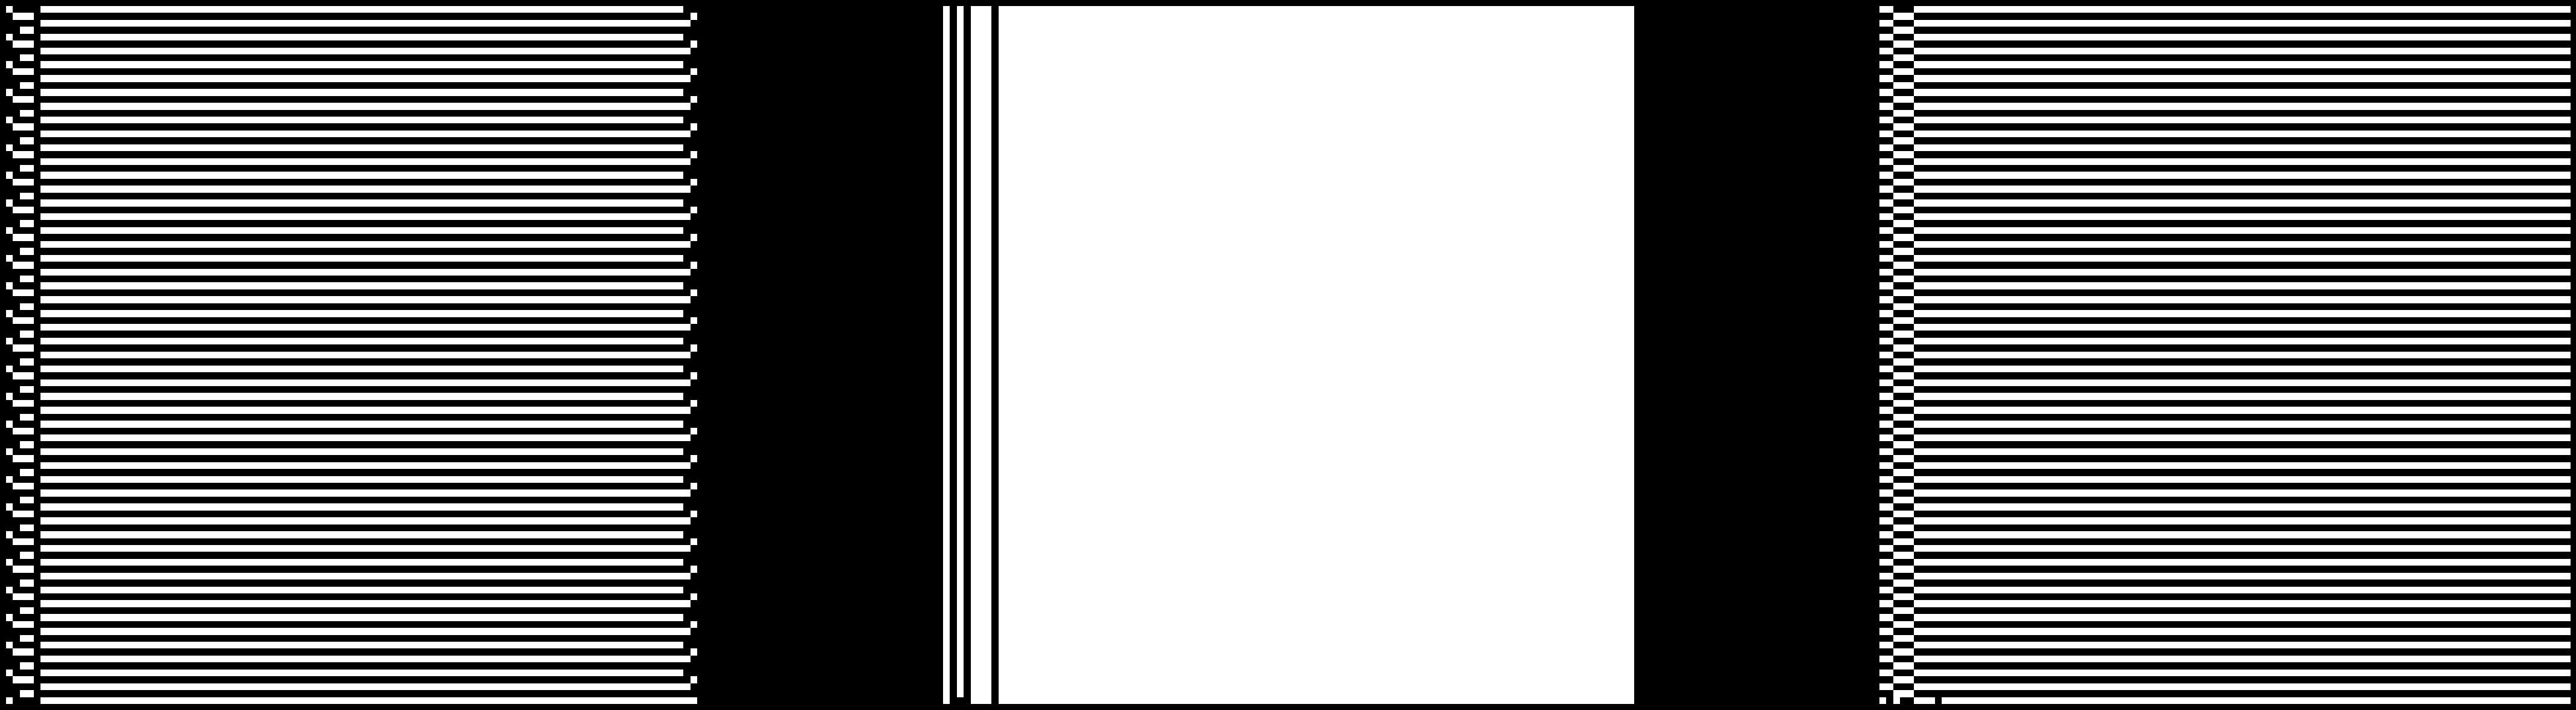

None


In [53]:
grids = (dynamics(91, 100, [1,2,3,4], 100), dynamics(76, 100, [1,2,3,7], 100), dynamics(23, 100, [1,8,3,4], 100))
print(plot_grid_multiple(grids, 3))

For example, let's code rule 11, 22 and 33 for the same initial conditions but taking symmetry, zero condition and in the standard form:

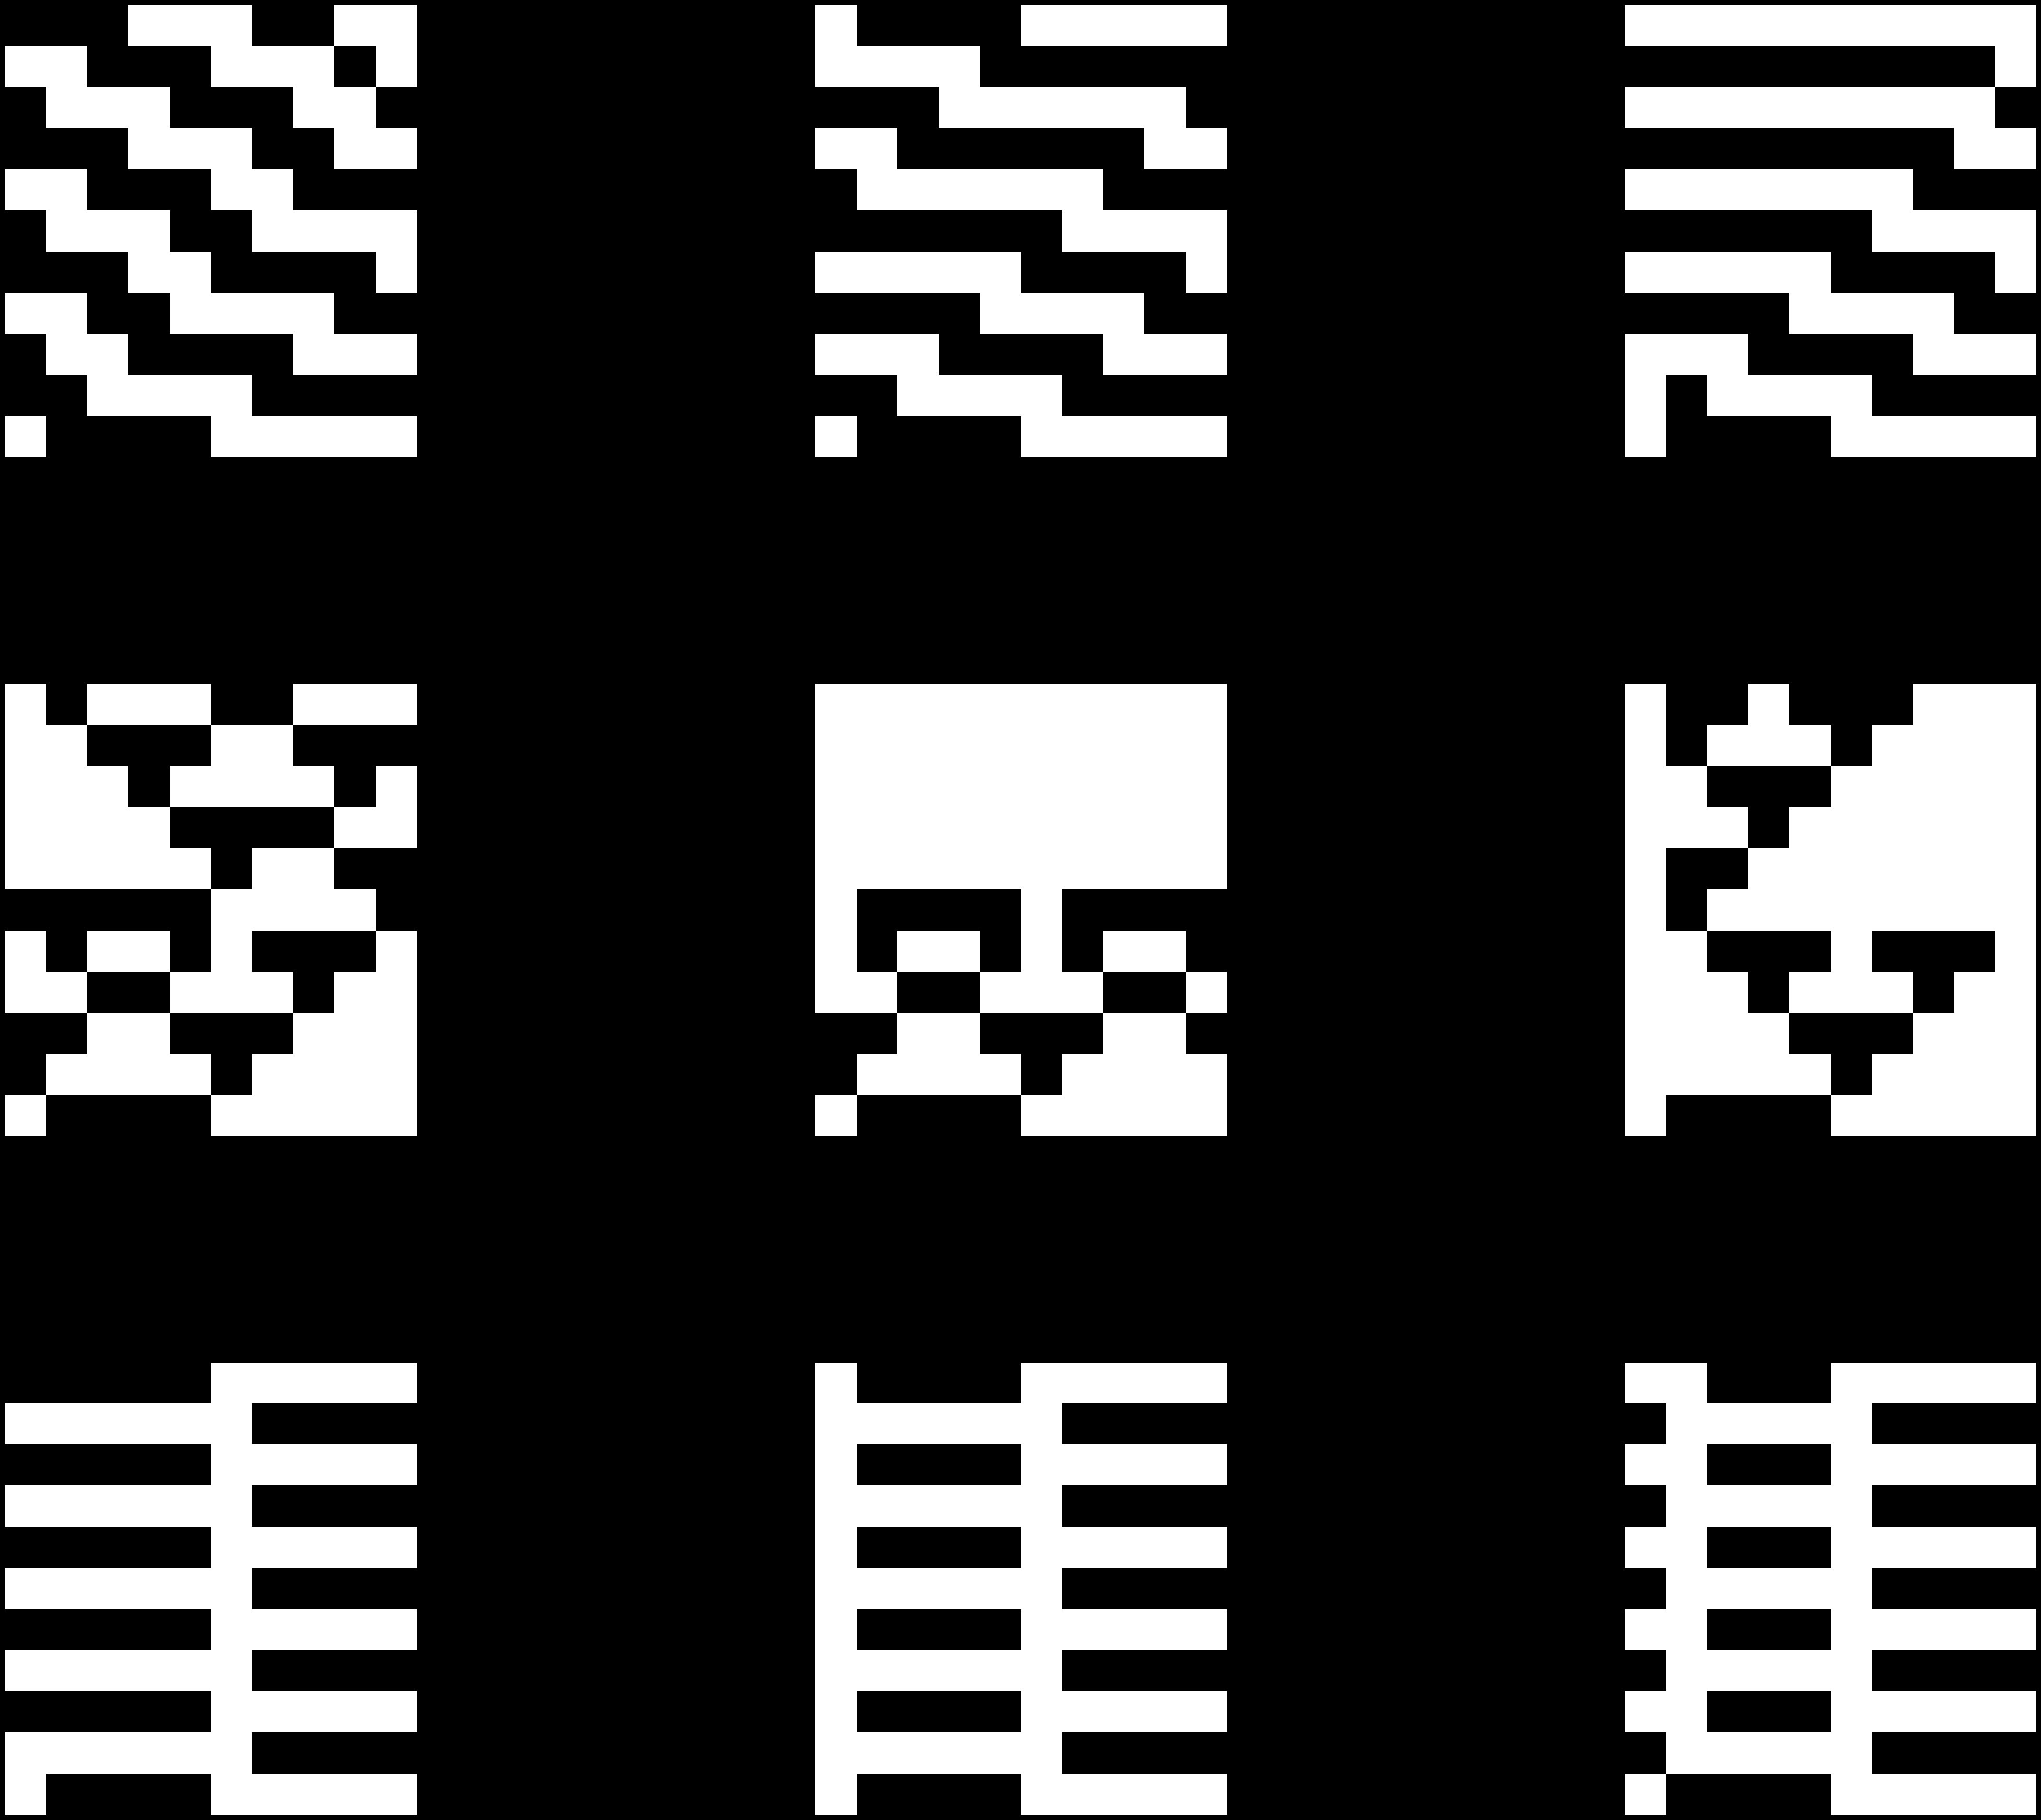

In [54]:
grids = (dynamics(11, 10, [1,2,3,4], 10), dynamics_periodic(11, 10, [1,2,3,4], 10), dynamics_reflection(11, 10, [1,2,3,4], 10),       dynamics(22, 10, [1,2,3,4], 10), dynamics_periodic(22, 10, [1,2,3,4], 10), dynamics_reflection(22, 10, [1,2,3,4], 10),       dynamics(33, 10, [1,2,3,4], 10), dynamics_periodic(33, 10, [1,2,3,4], 10), dynamics_reflection(33, 10, [1,2,3,4], 10))
plot_grid_multiple(grids, 3)

## 2. Examples and functions for chaotic grids

### 2.1) Rule 30 and functions for chaotic grids

It is known from literature that rule 30 is chaotic, meaning the final cell is highly susceptible to the initial cell's initial conditions. Let's plot it six times where one of the iniutial conditions is changed just once:

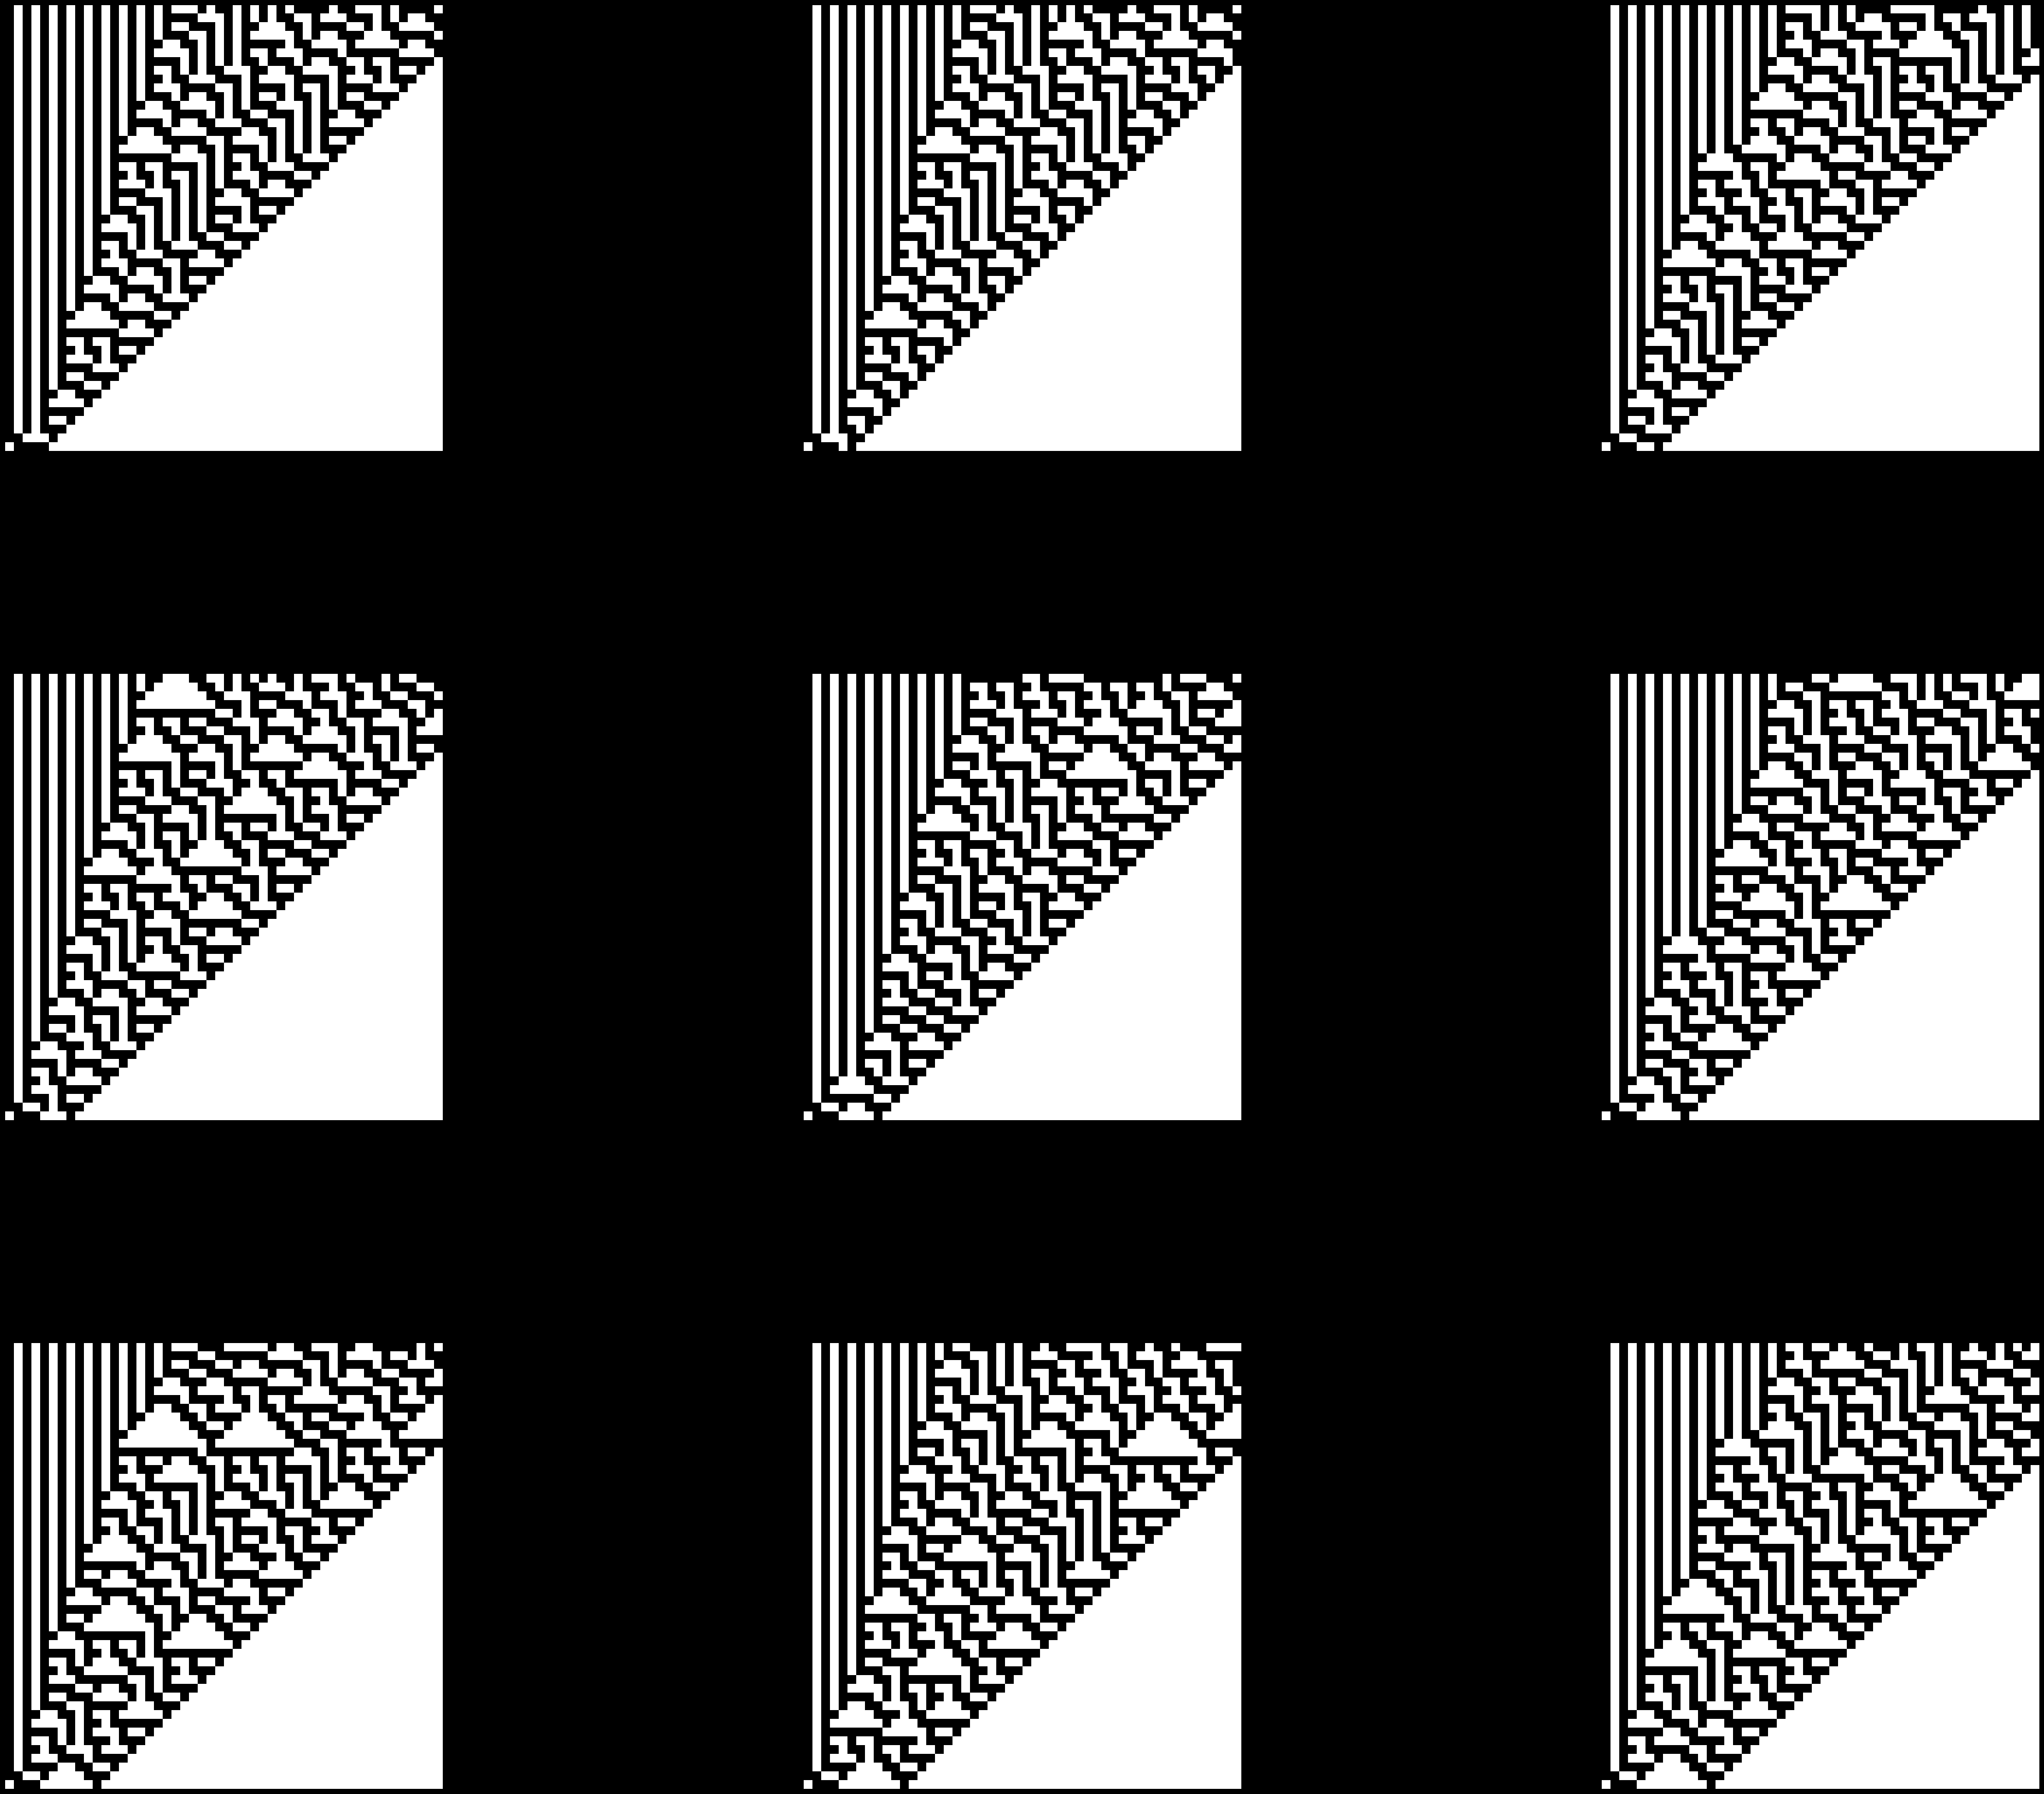

In [55]:
i=4
grids = (dynamics(30, 50, [1,2,3,i], 50), dynamics(30, 50, [1,2,3,i+1], 50), dynamics(30, 50, [1,2,3,i+2], 50),       dynamics(30, 50, [1,2,3,i+3], 50), dynamics(30, 50, [1,2,3,i+4], 50), dynamics(30, 50, [1,2,3,i+5], 50),       dynamics(30, 50, [1,2,3,i+6], 50), dynamics(30, 50, [1,2,3,i+7], 50), dynamics(30, 50, [1,2,3,i+8], 50))
plot_grid_multiple(grids, 3)

Because at such large scales it is hard to predict the chaos of the system, we can instead opt to redefine the function for the dynamics such that it only prints out the first and last cell, so the initial and final state of the system.

In [56]:
def dynamics_initialandfinal(rule_number, L, initial_conditions, timesteps):
    # Building up the lookup table
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropiate")
    
    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)
    for i in initial_conditions:
        row[i] = 1
    rows = [row.copy()] #So we take an independent "snapshot"

    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j - 1])) if j > 0 else '0'       # zero boundary
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j + 1])) if j < L - 1 else '0'   # zero boundary
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    
    return rows[0], "->", rows[-1]

In [57]:
print(dynamics_initialandfinal(34, 10, [1,3,5,7,9], 3), "\n", dynamics_initialandfinal(34, 10, [1,3,5,7,9], 10))

(array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1]), '->', array([1, 0, 1, 0, 1, 0, 1, 0, 0, 0])) 
 (array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1]), '->', array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))


As a different approach, we can take a function that counts the number of cells for two grids of the same size that have different values.

We start defining the function the following way:

In [58]:
def state_comparison(system_1, system_2):
    if system_1.shape != system_2.shape:
        raise ValueError("Systems must be of the same size")
    
    j = np.sum(system_1 != system_2)
    n = system_1.size
    
    return (j, j / n)

For two systems that are equal, the output must be zero.

In [59]:
system_1 = dynamics(3,10, [1,4,6], 10)
system_2 = system_1

print(state_comparison(system_1, system_2)) #Checks out

(0, 0.0)


In [60]:
system_1 = dynamics(89, 50, [10, 20, 30, 40, 49], 50)
system_2 = dynamics(89, 50, [11, 20, 30, 40, 49], 50)
system_1.shape[0]

print(state_comparison(system_1, system_2))

(530, 0.20784313725490197)


We can define a different function to only do this for a certain row or column at a given timestep. To compare a certain column or row, axis = 1 corresponds columns and axis = 0 corresponds to rows. 

It is relevant to mention that for rows that the inital conditions will have for index the last possible number, so it is important to consider this in the function such that the input timestep=0 prints out the first row.


In [61]:
def state_comparison_slice(system_1, system_2, timestep, axis):
    if axis == 1:
        i = timestep
        slice_1 = system_1[:, i]
        slice_2 = system_2[:, i]
    else:
        i = system_1.shape[0]-1-timestep
        slice_1 = system_1[i, :]
        slice_2 = system_2[i, :]

    if len(slice_1) != len(slice_2):
        raise ValueError("Systems must be of the same size")

    j = np.sum(slice_1 != slice_2)
    return ( j, j / len(slice_1))

For these initila conditions, the second one's is the first one's plus another one at 25:

In [62]:
system_1 = dynamics(30, 50, [10, 20, 25, 30, 40, 49], 50)
system_2 = dynamics(30, 50, [10, 20, 30, 40, 49], 50)

In [63]:
print(state_comparison_slice(system_1, system_2, 0, axis=0))

(1, 0.02)


Looking at the last row, determine the number of cells that are different:

In [64]:
print(state_comparison_slice(system_1, system_2, 50, axis=0)) 

(21, 0.42)


It is expected for this value to approach 50% (25), as will be seen later.

Another example is:

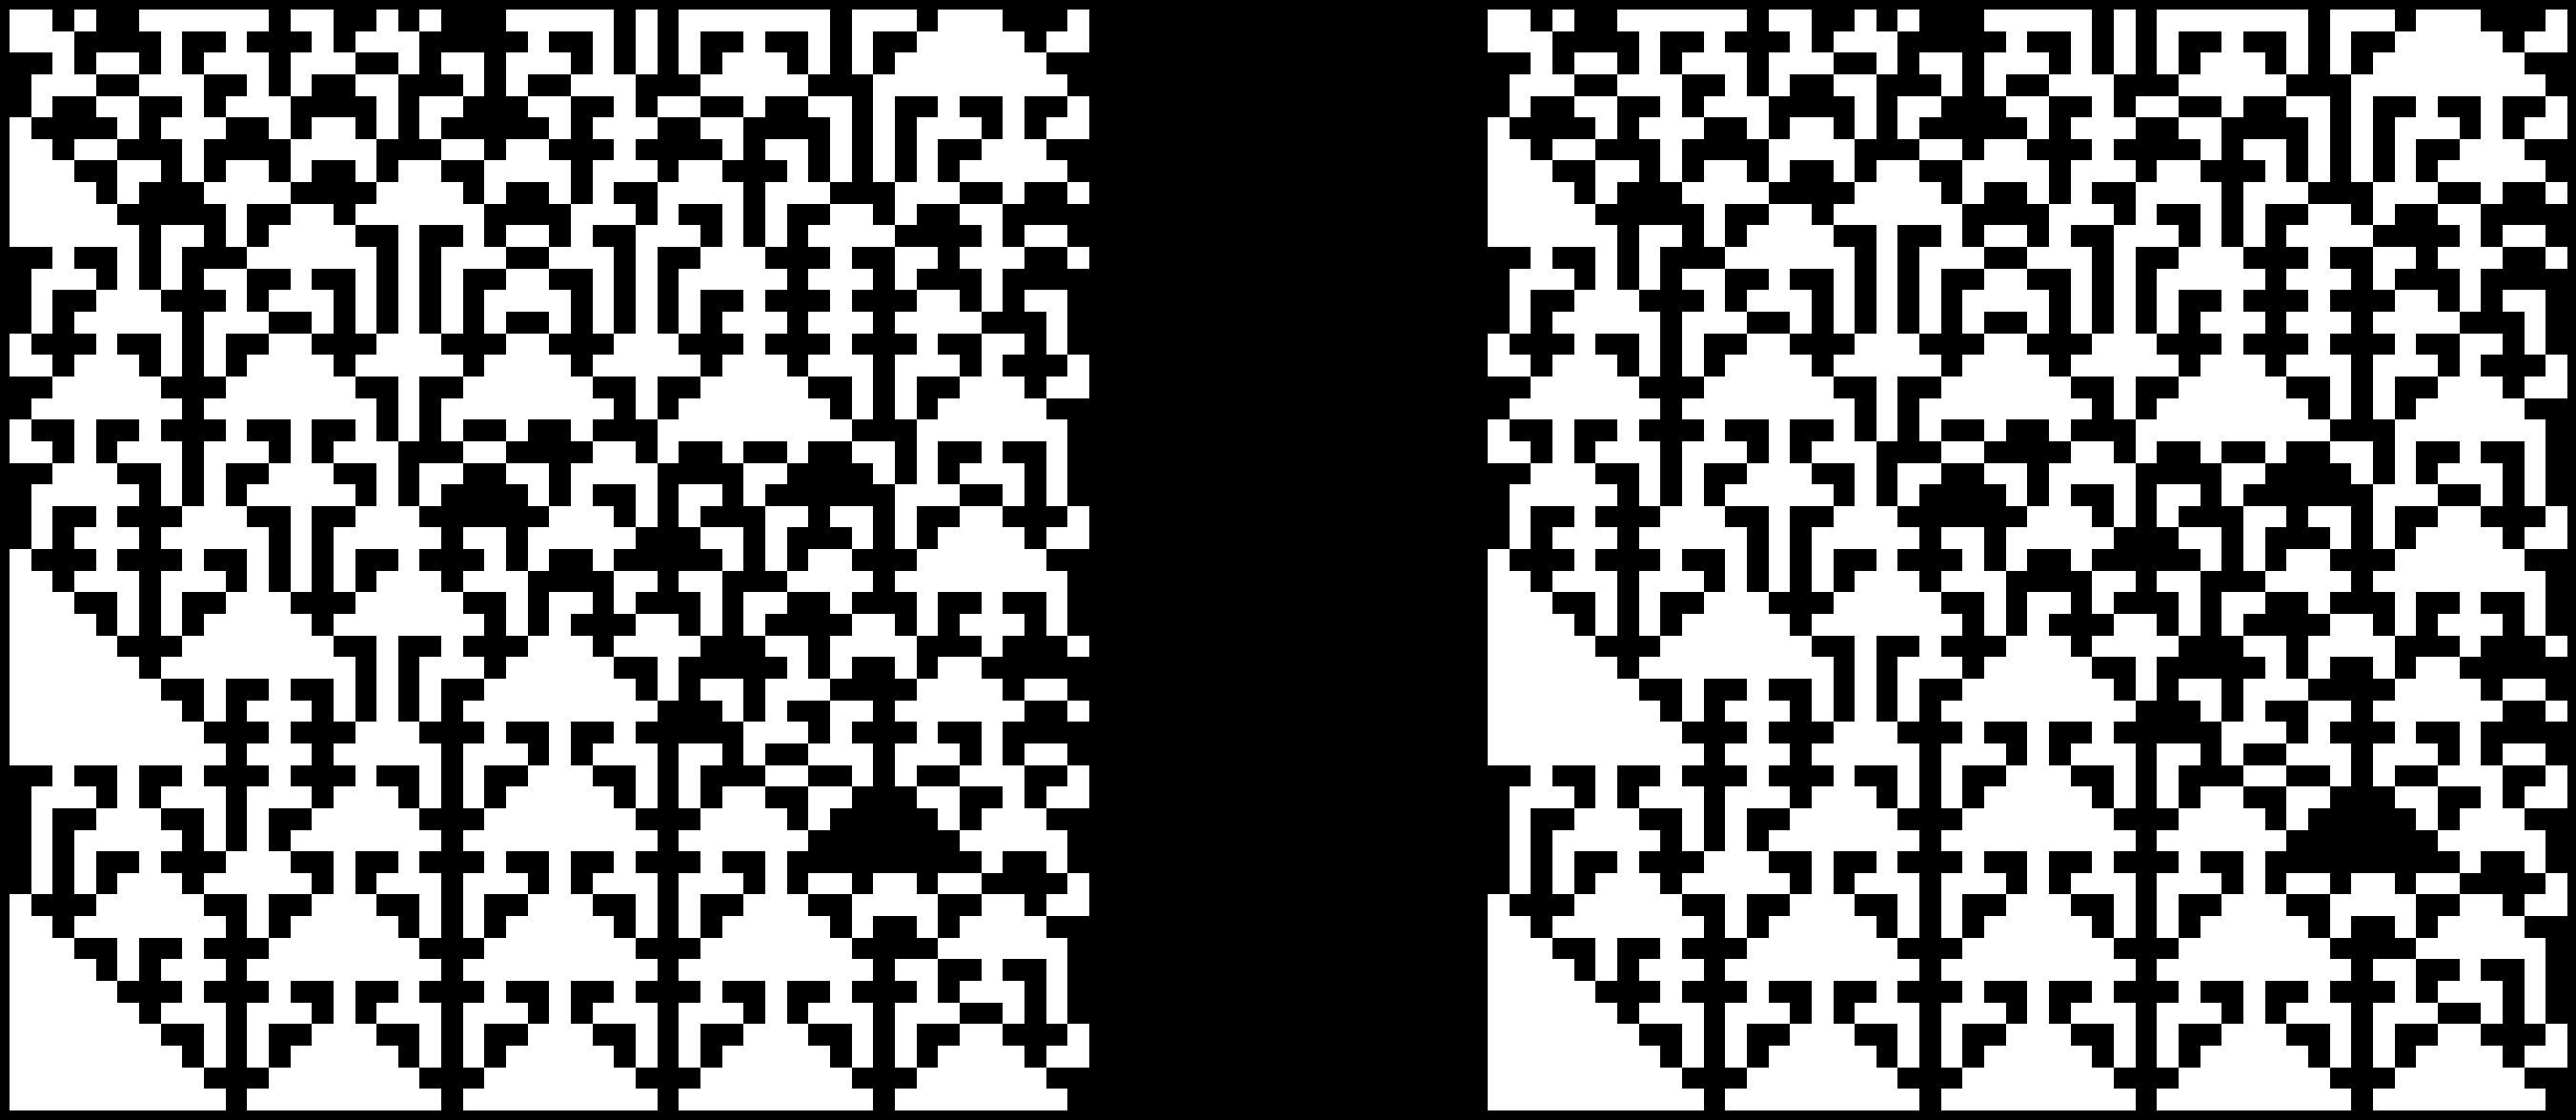

(19, 0.37254901960784315)


In [65]:

system_1 = dynamics(150, 50, [10, 20, 30, 40, 49], 50)
system_2 = dynamics(150, 50, [10, 22, 29, 40, 49], 50)

states = system_1, system_2

states = dynamics(150, 50, [10, 20, 30, 40, 49], 50), dynamics(150, 50, [10, 20, 30, 40, 49], 50)

plot_grid_multiple(states, 2)

print(state_comparison_slice(system_1, system_2, 23, axis = 1)) #The twenty-third timestep

This code to determine how many cells are different between two systems can help distinguish chaos or other types of evolution.

### 2.2) Study of columns

A function can be determined to plot a column so the time evolution of a single cell can be studied in time:

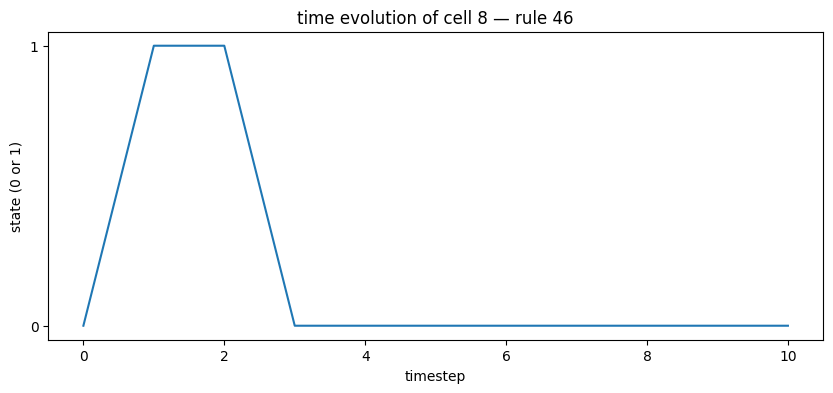

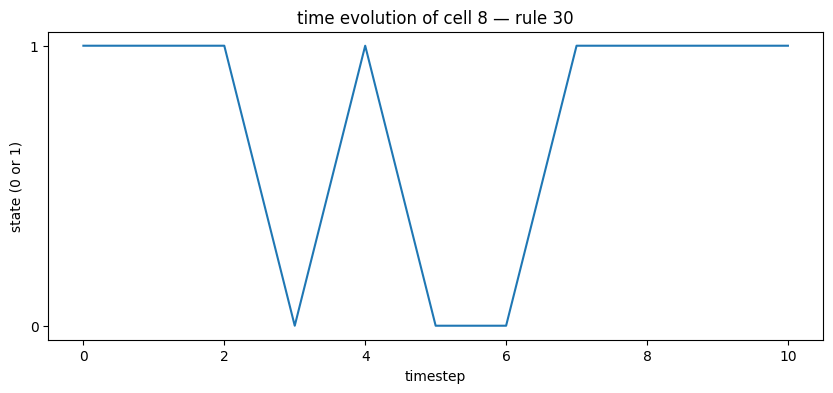

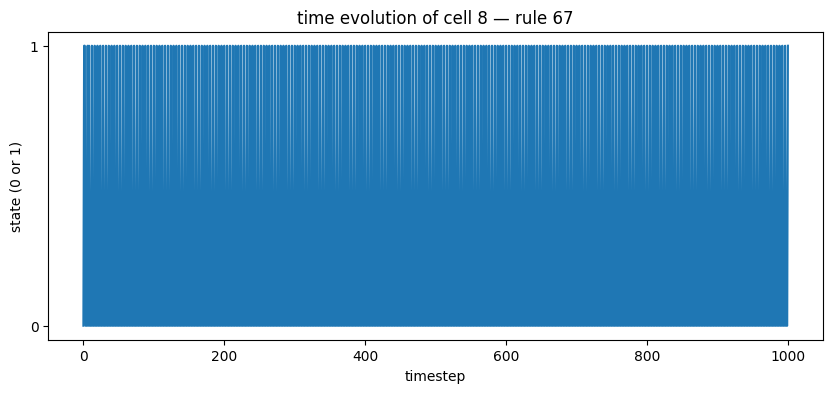

In [66]:
def plot_cell(rule, cell_i, timesteps, L):
    initial_conditions = np.random.randint(0, 2, size=L)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, L, row, timesteps)[::-1]  # chronological

    cell = system[:, cell_i]

    plt.figure(figsize=(10, 4))
    plt.plot(cell)
    plt.xlabel('timestep')
    plt.ylabel('state (0 or 1)')
    plt.title(f'time evolution of cell {cell_i} — rule {rule}')
    plt.yticks([0, 1])
    plt.savefig("Fourier")
    plt.show()

plot_cell(46, 8, 10, 10)
plot_cell(30, 8, 10, 10)
plot_cell(67, 8, 1000, 1000)

To make it more visual:

In [89]:
def plot_column(arr, col, cols=100):
    arr = arr[::-1] if arr.ndim > 1 else arr  # restore chronological order (t=0 first)
    column = arr[:, col] if arr.ndim > 1 else arr
    n = len(column)

    def render_segment(seg, start_t):
        print(f'{"":7}┌─┐')
        for i, x in enumerate(seg):
            t = start_t + i
            print(f't={t:<4} │{"■" if x else "□"}│')
        print(f'{"":7}└─┘')

    segments = [column[i:i+cols] for i in range(0, n, cols)]
    for idx, seg in enumerate(segments):
        render_segment(seg, idx * cols)
        if idx < len(segments) - 1:
            print()

An example with a given system:

In [92]:
system = dynamics(43, 30, [1,6,24], 30)
plot_column(system, col = 5, cols = 5)

       ┌─┐
t=0    │□│
t=1    │■│
t=2    │□│
t=3    │■│
t=4    │■│
       └─┘

       ┌─┐
t=5    │□│
t=6    │□│
t=7    │■│
t=8    │□│
t=9    │□│
       └─┘

       ┌─┐
t=10   │■│
t=11   │□│
t=12   │□│
t=13   │■│
t=14   │□│
       └─┘

       ┌─┐
t=15   │□│
t=16   │■│
t=17   │□│
t=18   │□│
t=19   │■│
       └─┘

       ┌─┐
t=20   │□│
t=21   │□│
t=22   │■│
t=23   │□│
t=24   │□│
       └─┘

       ┌─┐
t=25   │■│
t=26   │□│
t=27   │□│
t=28   │■│
t=29   │□│
       └─┘

       ┌─┐
t=30   │□│
       └─┘


To plot multiple cells on the same plot so that you can regard the evolution of multiple cells at the same time (specially useful if they are neighbors):

In [69]:
def plot_multiple_cells(*cells):
    fig, ax = plt.subplots(figsize=(15, 4))

    for rule, initial_conditions, timesteps, L, cell_i in cells:
        system = dynamics(rule, L, initial_conditions, timesteps)[::-1]  # chronological
        ax.plot(system[:, cell_i], label=f'rule {rule} — cell {cell_i}')

    ax.set_xlabel('timestep')
    ax.set_ylabel('state (0 or 1)')
    ax.set_yticks([0, 1])
    ax.legend()
    plt.tight_layout()
    plt.show()

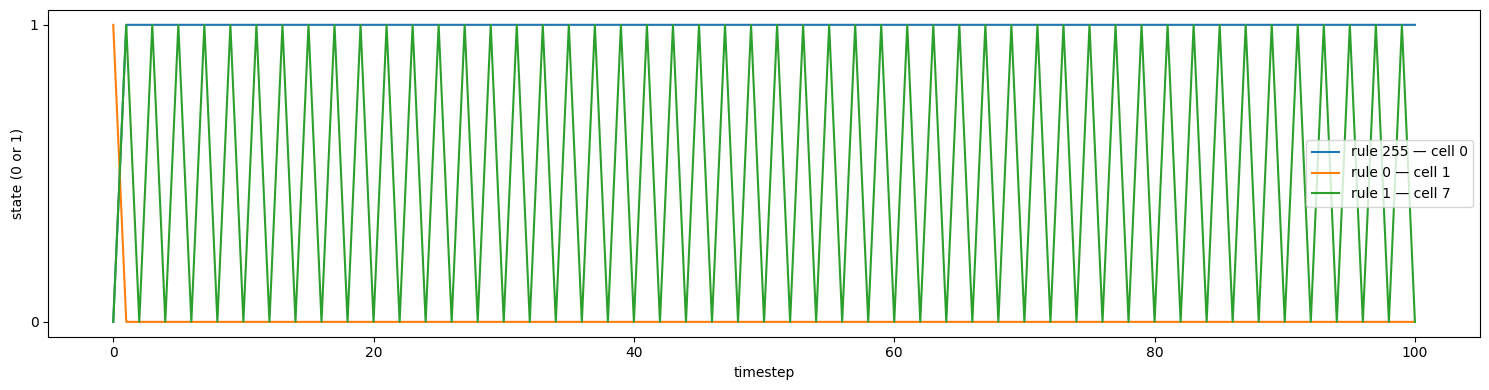

In [70]:
cell_1 = (255, [1,2,3], 100, 10, 0) #rule, initial conditions, timesteps, L, index of the cell
cell_2 = (0, [1,0,0], 100, 10, 1)
cell_3 = (1, [0,2,3], 100, 10, 7)

plot_multiple_cells(cell_1, cell_2, cell_3)

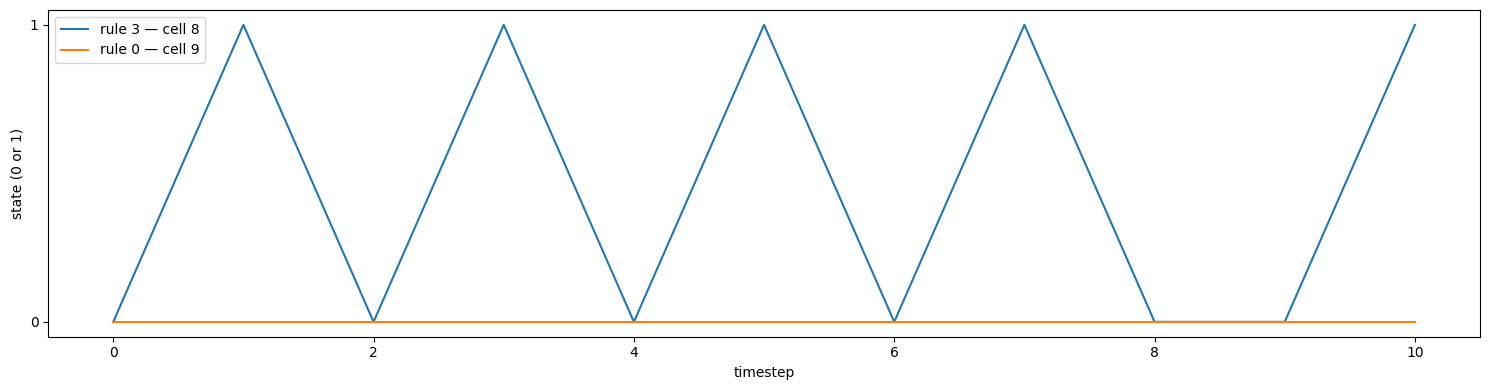

In [71]:
cell_4 = (3, [0,2,3], 10, 10, 8)
cell_5 = (0, [0,2,3], 10, 10, 9)

plot_multiple_cells(cell_4, cell_5)

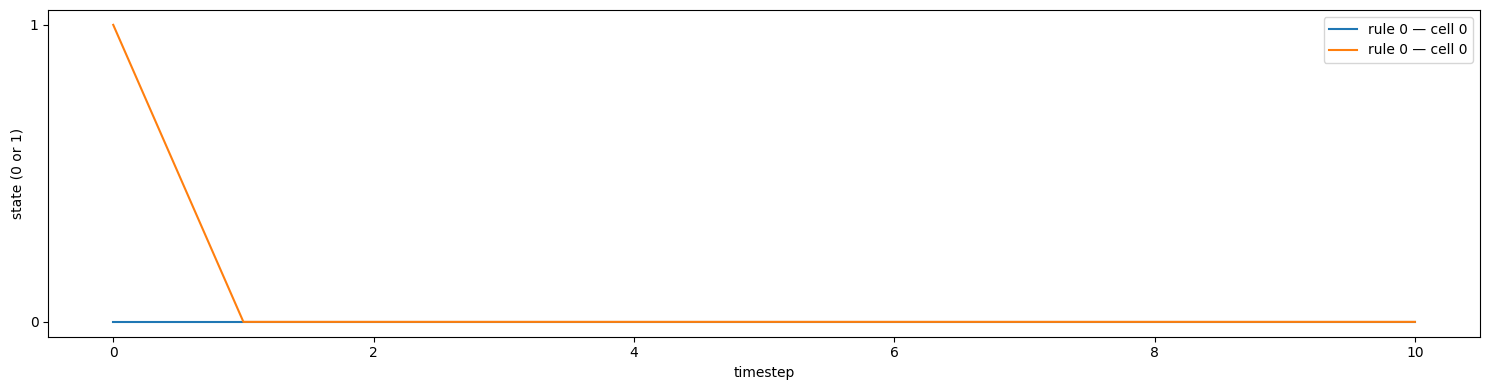

In [72]:
cell_4 = (0, [1,2,3], 10, 10, 0)
cell_5 = (0, [0,2,3], 10, 10, 0)

plot_multiple_cells(cell_4, cell_5)

### 2.3) Fourier transformation of the evolution of single cells:
https://www.youtube.com/watch?v=jNC0jxb0OxE

https://www.youtube.com/watch?v=uWqTkwkj-1o

Because individual cells oscillate between two states through time, a fourier analysis can be performed and the frequency and power spectrum for this oscillation obtained.

Relevant formulas are the following:
- Fourier transform (integrated in Numpy): F = sum from n to N-1 (x*e**((-2pi*ik)/N)
- Power spectrum: P(f) = |F(f)|**2
- Frequency: Will depend on the behaviour of the cell


aliasing fft

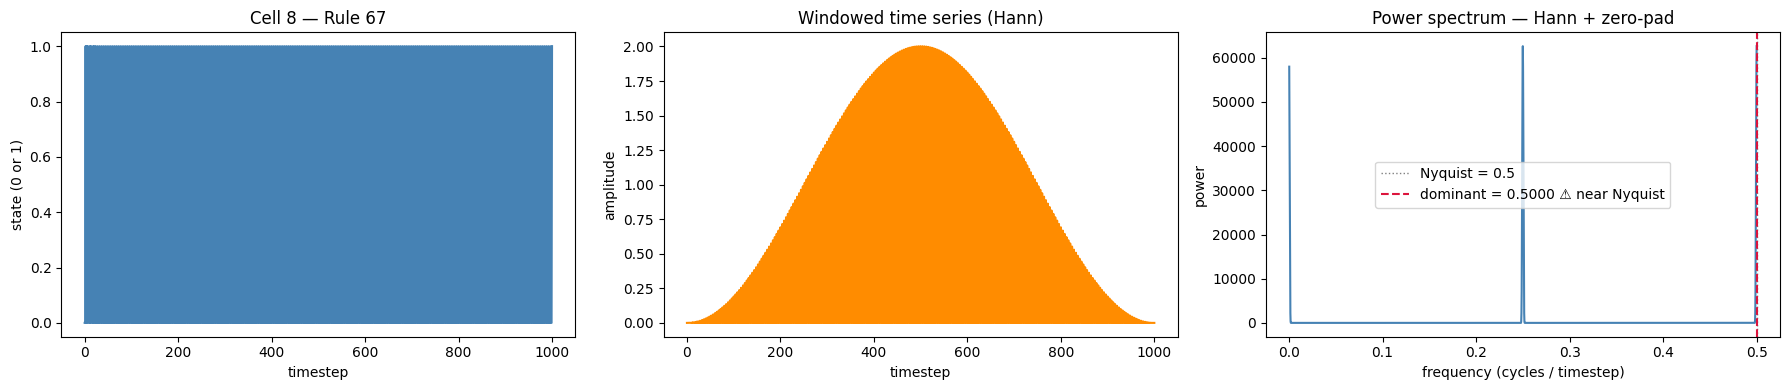

Sampling rate   : 1 sample / timestep  →  Nyquist = 0.5 cycles/timestep
Dominant freq   : 0.5000 cycles/timestep
Period          : 2.0 timesteps
⚠  WARNING: dominant frequency is near the Nyquist limit (0.5).
   If the true period is shorter than 2 timesteps, aliasing has occurred
   and this peak is a folded artefact, not a real frequency.
✓  Hann window applied  — spectral leakage suppressed
✓  Zero-padded to 4096 points — peak location interpolated


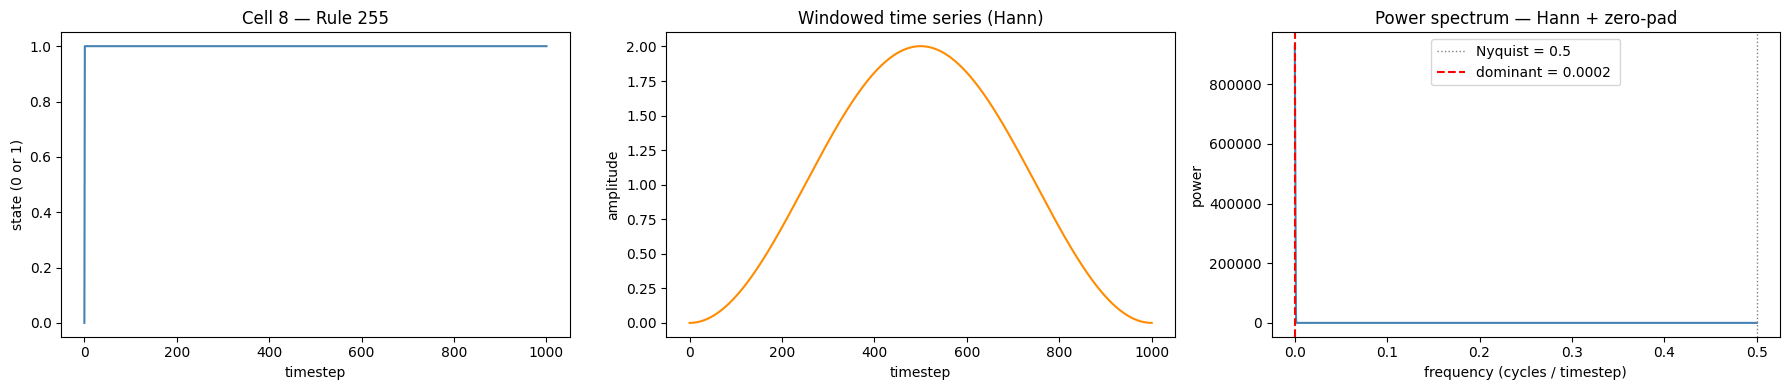

Sampling rate   : 1 sample / timestep  →  Nyquist = 0.5 cycles/timestep
Dominant freq   : 0.0002 cycles/timestep
Period          : 4096.0 timesteps
✓  Hann window applied  — spectral leakage suppressed
✓  Zero-padded to 4096 points — peak location interpolated


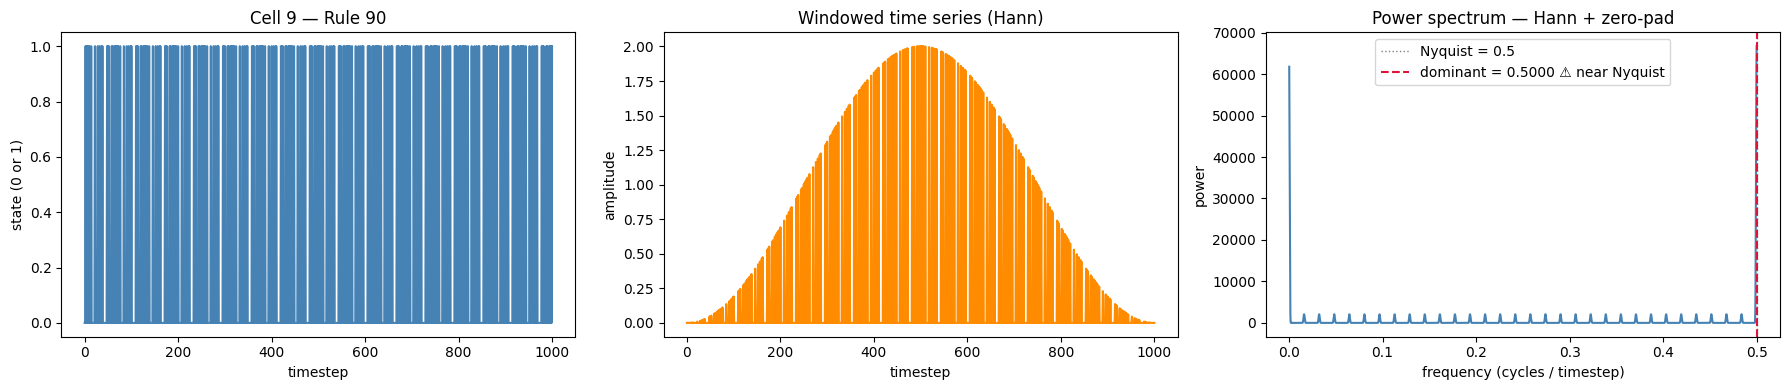

Sampling rate   : 1 sample / timestep  →  Nyquist = 0.5 cycles/timestep
Dominant freq   : 0.5000 cycles/timestep
Period          : 2.0 timesteps
⚠  WARNING: dominant frequency is near the Nyquist limit (0.5).
   If the true period is shorter than 2 timesteps, aliasing has occurred
   and this peak is a folded artefact, not a real frequency.
✓  Hann window applied  — spectral leakage suppressed
✓  Zero-padded to 4096 points — peak location interpolated


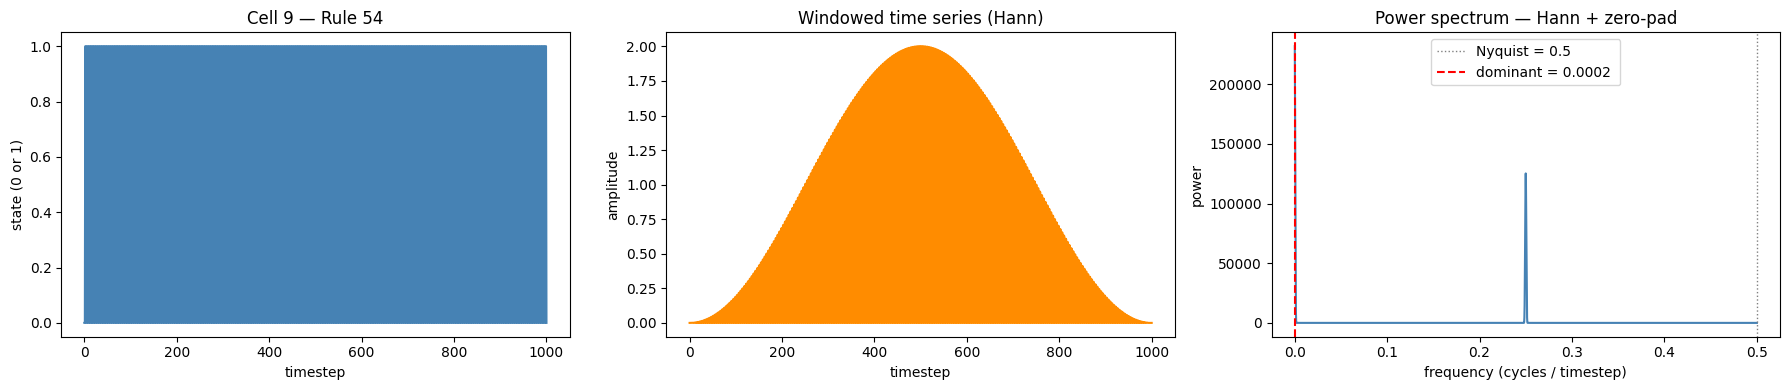

Sampling rate   : 1 sample / timestep  →  Nyquist = 0.5 cycles/timestep
Dominant freq   : 0.0002 cycles/timestep
Period          : 4096.0 timesteps
✓  Hann window applied  — spectral leakage suppressed
✓  Zero-padded to 4096 points — peak location interpolated


In [73]:
def fourier_cell(rule_number, L, initial_conditions, timesteps, cell_index,
                 apply_window=True, zero_pad=True):
    """
    Fourier analysis of a single CA cell's time series, with aliasing mitigations:
      - Hann windowing: reduces spectral leakage (a form of aliasing from finite signals)
      - Zero-padding: interpolates the spectrum for sharper peak visualisation
    """
    grid = dynamics(rule_number, L, initial_conditions, timesteps)
    time_series = grid[::-1, cell_index].astype(float)   # shape (timesteps+1,)
    N = len(time_series)

    #Anti-aliasing: Hann window 
    # A CA cell is a binary signal sampled at 1 sample/timestep.
    # Nyquist limit = 0.5 cycles/timestep — we can't exceed this, so classical
    # aliasing isn't the problem. Problem is spectral leakage:
    # abruptly truncating a finite signal smears energy across all frequencies,
    # making weak periodic components invisible behind the "leaked" noise.
    # A window tapers the edges to zero, suppressing leakage. All explanations taken from the video
    if apply_window:
        window = np.hanning(N) # To create a commonly used Hann window
        window /= window.mean()          # normalise so mean power is preserved
        time_series_w = time_series * window
    else:
        time_series_w = time_series

    # Zero-padding 
    # Pad to the next power of 2 beyond 4× the original length.
    # This does not add new frequency resolution — it just interpolates the
    # spectrum so peaks are easier to see and the dominant-freq estimate is
    # more accurate (reduces picket-fence error), which is the explanation from the video
    if zero_pad:
        N_padded = 1
        while N_padded < 4 * N:
            N_padded *= 2
    else:
        N_padded = N

    # FFT & power spectrum
    fft = np.fft.rfft(time_series_w, n=N_padded)   # rfft: real input → half spectrum only
    power  = np.abs(fft) ** 2
    freqs  = np.fft.rfftfreq(N_padded)                # 0 … 0.5 cycles/timestep

    # Exclude DC (index 0), it just reflects the mean value of the signal
    pos = freqs > 0

    # Dominant frequency 
    dominant_idx  = np.argmax(power[pos])
    dominant_freq = freqs[pos][dominant_idx]

    # Aliasing-risk annotation 
    # Nyquist = 0.5 cycles/timestep (fixed by the 1-step sampling rate).
    # Flag if the dominant peak sits above 80% of Nyquist, it should be close enough
    # to the fold-over point that interpretation should be cautious.
    nyquist = 0.5
    alias_warning = dominant_freq > 0.8 * nyquist

    # Plots 
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Left: raw time series
    axes[0].plot(time_series, color='steelblue')
    axes[0].set_title(f"Cell {cell_index} — Rule {rule_number}")
    axes[0].set_xlabel("timestep")
    axes[0].set_ylabel("state (0 or 1)")

    # Middle: windowed time series (so the user can see what was actually transformed)
    if apply_window:
        axes[1].plot(time_series_w, color='darkorange')
        axes[1].set_title("Windowed time series (Hann)")
    else:
        axes[1].plot(time_series_w, color='darkorange')
        axes[1].set_title("Time series (no window)")
    axes[1].set_xlabel("timestep")
    axes[1].set_ylabel("amplitude")

    # Right: power spectrum
    axes[2].plot(freqs[pos], power[pos], color='steelblue')
    axes[2].axvline(nyquist, color='gray', linestyle=':', linewidth=1,
                    label=f"Nyquist = {nyquist}")
    axes[2].axvline(dominant_freq,
                    color='red' if not alias_warning else 'crimson',
                    linestyle='--',
                    label=f"dominant = {dominant_freq:.4f} {'⚠ near Nyquist' if alias_warning else ''}")
    axes[2].set_title(f"Power spectrum — {'Hann + zero-pad' if apply_window else 'raw FFT'}")
    axes[2].set_xlabel("frequency (cycles / timestep)")
    axes[2].set_ylabel("power")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    #  Values
    print(f"Sampling rate   : 1 sample / timestep  →  Nyquist = {nyquist} cycles/timestep")
    print(f"Dominant freq   : {dominant_freq:.4f} cycles/timestep")
    print(f"Period          : {1/dominant_freq:.1f} timesteps")
    if alias_warning:
        print(f"⚠  WARNING: dominant frequency is near the Nyquist limit ({nyquist}).")
        print(f"   If the true period is shorter than 2 timesteps, aliasing has occurred")
        print(f"   and this peak is a folded artefact, not a real frequency.")
    if apply_window:
        print("✓  Hann window applied  — spectral leakage suppressed")
    if zero_pad:
        print(f"✓  Zero-padded to {N_padded} points — peak location interpolated")

fourier_cell(67, 10, [1,7], 1000, cell_index=8)
fourier_cell(255, 10, [1,7], 1000, cell_index=8)
fourier_cell(90, 10, [1,7], 1000, cell_index = 9)
fourier_cell(54, 10, [1,7], 1000, cell_index = 9)

This function can be expanded such that it will show the evolution and fourier analysis of all the cells in the lattice, performing this function for a big lattice will occupy a large space:

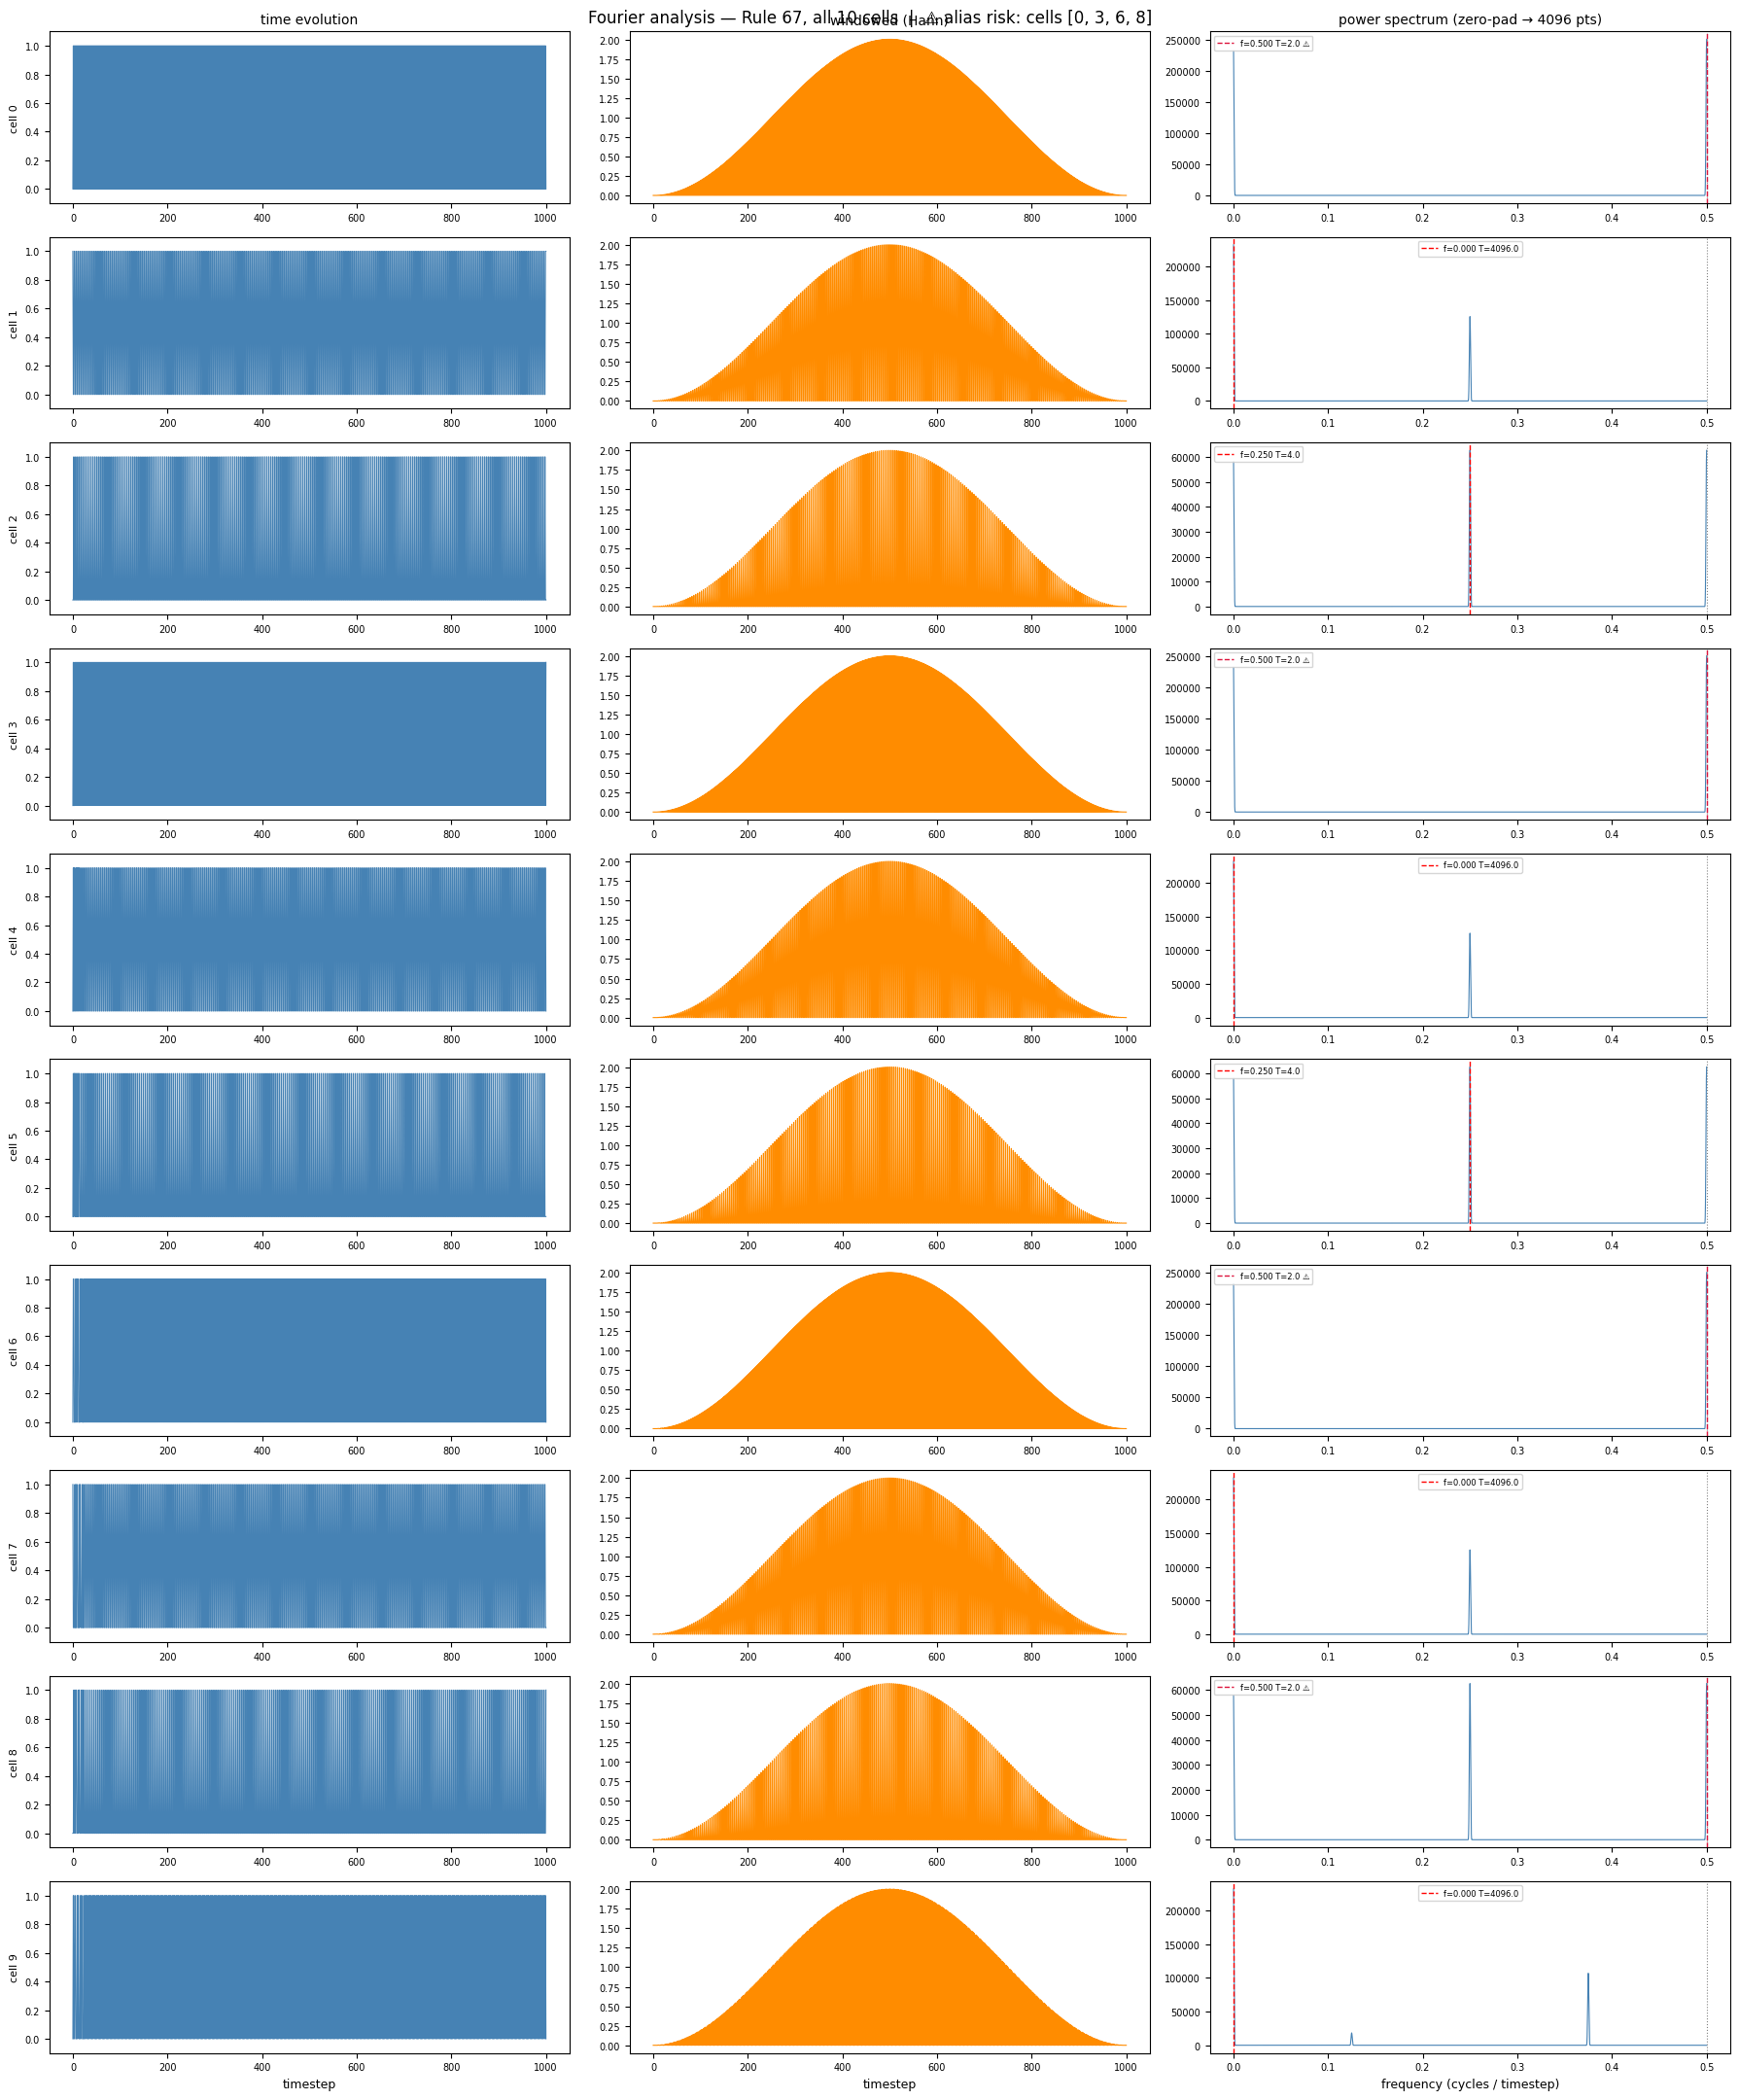

Nyquist limit : 0.5 cycles/timestep  (sampling rate = 1/timestep)
Window        : Hann (leakage suppressed)
Zero-pad      : 1001 → 4096 points
⚠  Cells with dominant freq > 0.8×Nyquist: [0, 3, 6, 8]
   These peaks may be folded artefacts — true period could be < 2 timesteps.


In [74]:
def fourier_all_cells(rule_number, L, initial_conditions, timesteps,
                      apply_window=True, zero_pad=True):

    grid        = dynamics(rule_number, L, initial_conditions, timesteps)
    time_series = grid[::-1]          # shape (timesteps+1, L), time goes forward
    N           = time_series.shape[0]
    nyquist     = 0.5                 # fixed: 1 sample/timestep → Nyquist = 0.5


    if zero_pad:
        N_padded = 1
        while N_padded < 4 * N:
            N_padded *= 2
    else:
        N_padded = N

    if apply_window:
        window = np.hanning(N)
        window = window / window.mean()   # preserve mean power
    else:
        window = np.ones(N)

    freqs = np.fft.rfftfreq(N_padded)    # 0 … 0.5, shared frequency axis
    pos   = freqs > 0                    # drop DC bin

    fig, axes = plt.subplots(L, 3, figsize=(18, 2.2 * L))
    if L == 1:
        axes = axes[np.newaxis, :]

    alias_cells = []   # collect cells that triggered the Nyquist warning

    for cell in range(L):
        signal   = time_series[:, cell].astype(float)
        windowed = signal * window

        fft   = np.fft.rfft(windowed, n=N_padded)
        power = np.abs(fft) ** 2

        dominant_freq = freqs[pos][np.argmax(power[pos])]
        period        = 1 / dominant_freq
        alias_risk    = dominant_freq > 0.8 * nyquist

        if alias_risk:
            alias_cells.append(cell)

        axes[cell, 0].plot(signal, color='steelblue', linewidth=0.8)
        axes[cell, 0].set_ylabel(f"cell {cell}", fontsize=8)
        axes[cell, 0].set_ylim(-0.1, 1.1)
        axes[cell, 0].tick_params(labelsize=7)

        axes[cell, 1].plot(windowed, color='darkorange', linewidth=0.8)
        axes[cell, 1].set_ylim(windowed.min() - 0.1, windowed.max() + 0.1)
        axes[cell, 1].tick_params(labelsize=7)

        line_color = 'crimson' if alias_risk else 'red'
        axes[cell, 2].plot(freqs[pos], power[pos], color='steelblue', linewidth=0.8)
        axes[cell, 2].axvline(nyquist, color='gray', linestyle=':', linewidth=0.8)
        axes[cell, 2].axvline(dominant_freq, color=line_color, linestyle='--',
                              linewidth=1,
                              label=(f"f={dominant_freq:.3f} T={period:.1f}"
                                     + (" ⚠" if alias_risk else "")))
        axes[cell, 2].legend(fontsize=6)
        axes[cell, 2].tick_params(labelsize=7)

    axes[0, 0].set_title("time evolution", fontsize=10)
    axes[0, 1].set_title(f"windowed ({'Hann' if apply_window else 'none'})", fontsize=10)
    axes[0, 2].set_title(f"power spectrum (zero-pad → {N_padded} pts)", fontsize=10)

    axes[-1, 0].set_xlabel("timestep", fontsize=9)
    axes[-1, 1].set_xlabel("timestep", fontsize=9)
    axes[-1, 2].set_xlabel("frequency (cycles / timestep)", fontsize=9)

    fig.suptitle(
        f"Fourier analysis — Rule {rule_number}, all {L} cells"
        + (f"  |  ⚠ alias risk: cells {alias_cells}" if alias_cells else ""),
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    print(f"Nyquist limit : {nyquist} cycles/timestep  (sampling rate = 1/timestep)")
    print(f"Window        : {'Hann (leakage suppressed)' if apply_window else 'none'}")
    print(f"Zero-pad      : {N} → {N_padded} points")
    if alias_cells:
        print(f"⚠  Cells with dominant freq > 0.8×Nyquist: {alias_cells}")
        print("   These peaks may be folded artefacts — true period could be < 2 timesteps.")
    else:
        print("✓  No cells flagged for aliasing risk.")

fourier_all_cells(67, 10, [1,7], 1000)

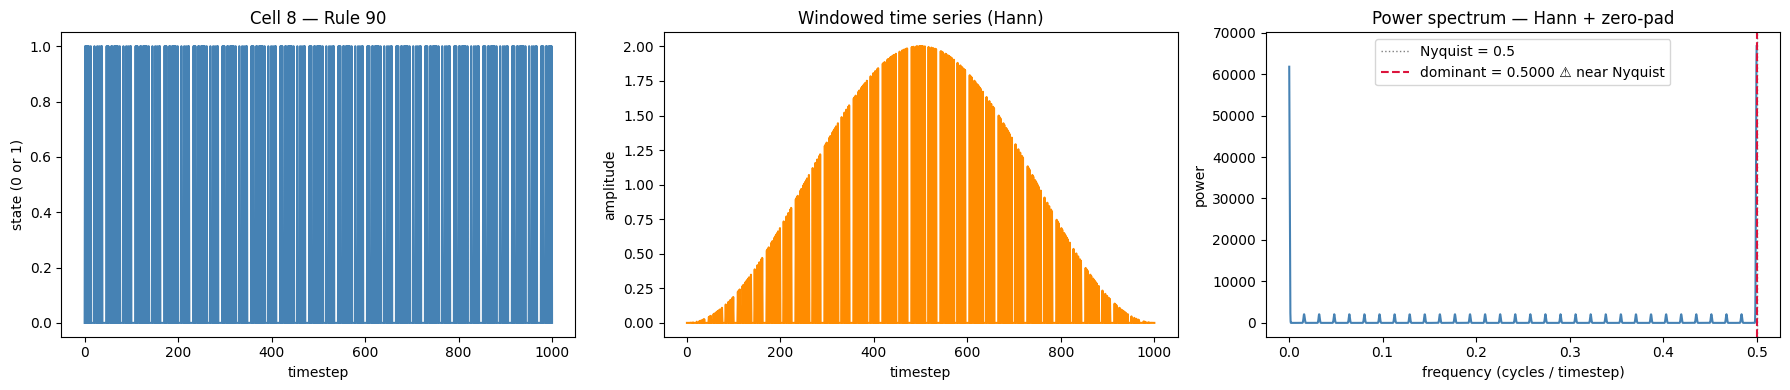

Sampling rate   : 1 sample / timestep  →  Nyquist = 0.5 cycles/timestep
Dominant freq   : 0.5000 cycles/timestep
Period          : 2.0 timesteps
⚠  WARNING: dominant frequency is near the Nyquist limit (0.5).
   If the true period is shorter than 2 timesteps, aliasing has occurred
   and this peak is a folded artefact, not a real frequency.
✓  Hann window applied  — spectral leakage suppressed
✓  Zero-padded to 4096 points — peak location interpolated


<Figure size 640x480 with 0 Axes>

In [75]:
fourier_cell(90, 10, [1,7], 1000, cell_index=8) 
plt.savefig("hh")

## 3. Ways to classify behaviours of cellular automata

### 3.1) Stephen Wolfram's classes:

Stephen Wolfram distinguished four distinct classes of cellular automata based on their long term behaviour ("A New Kind of Science" (2002)):
- Class I: Converges to a uniforms state(oppossite of chaotic): Regardles of the initial conditions, it will converge to the same final state, so over a large time initial.
- Class II: Converges to periodic / stable structures
- Class III (chaotic): Converges to randomness / noise
- Class IV (complex, edge between order and chaos): Has a heterogeneous structure.

#### 3.1.1) Class I

A function can be determined to regard if a rule corresponds to class 1, it takes a 1000x1000 grid with a given rule and plots the system, then the system is another time such that all the plots are plotted with random initial conditions. 

If the number of cells for the last stage is less than 10% of the total cells at that stage, then it is classified as class I.

In [ ]:
def rule_1(rule):
    initial_conditions_1 = np.random.randint(0, 2, size=1000)
    initial_conditions_2 = np.random.randint(0, 2, size=1000)
    row_1 = list(np.where(initial_conditions_1 == 1)[0])   
    row_2 = list(np.where(initial_conditions_2 == 1)[0])
    system_1 = dynamics(rule, 1000, row_1, 1000)
    system_2 = dynamics(rule, 1000, row_2, 1000)

    if state_comparison_slice(system_1, system_2, 999, axis=0)[1] <= 0.1:
        return True
    else:
        return False

Rule 0, 8 and 32 converge to all zero, so they are class 1:

In [123]:
print(rule_1(8), rule_1(160), rule_1(32))

print(rule_1(250)) #Converges to all 1

True True True
True


Rule 204, 232 and 108 converge to stable patterns:

In [78]:
print(rule_1(204), rule_1(232), rule_1(108))

True True True


#### 3.1.2) Class II
For class II, we can use the fucntion defined earlier for measuring the total number of cells acros the whole grid that are different. Because it gives place to stable periodic structures, then we check if for a throusand timesteps there is any kind of period, which should manifest itself within 1000 timesteps.

In [ ]:
def rule_2(rule_number, L=50, timesteps=1000,
                transient_cutoff=0.5, max_period=20, threshold=0.85): # More computationally expensive to compute compared to all other classes
    """
    Identify whether a CA rule is Class II (periodic / stable structures).

    Strategy: after discarding the transient, check whether the spatial grid
    repeats with a short period. Class II rules always find a cycle;
    Class III/IV rules don't (class IV only has localised periodicity ).

    Parameters
    ----------
    rule_number     : Wolfram rule (0–255)
    L               : lattice width
    timesteps       : how long to run (needs to be long enough for transient to die)
    transient_cutoff: fraction of steps to discard as transient
    max_period      : longest cycle length to search for (1 = fixed point, 2 = flip, …)
    threshold       : fraction of ICs that must show periodicity to call it Class II

    Returns
    -------
    bool, dict   : classification + diagnostic info
    """
    
    initial_conditions = [
        np.random.randint(0, 2, L),
        np.random.randint(0, 2, L),
        np.random.randint(0, 2, L),
    ]
    single_seed = np.zeros(L, dtype=int)
    single_seed[L // 2] = 1
    initial_conditions.append(single_seed)

    transient_step = int(timesteps * transient_cutoff)
    results = []   # (is_periodic, period_found) per IC

    for ic in initial_conditions:
        grid          = dynamics(rule_number, L, ic, timesteps)
        grid          = grid[::-1]                      # time forward, shape (T+1, L)
        post_transient = grid[transient_step:]

        found_period  = None

        # search for the shortest period p such that row[t] == row[t+p] for all t
        for p in range(1, max_period + 1):
            # compare every row with the row p steps ahead
            # if they all match, the grid is cycling with period p
            rows_a = post_transient[:-p]
            rows_b = post_transient[p:]
            if np.all(rows_a == rows_b):
                found_period = p
                break   # shortest period wins

        results.append(found_period)

    periodic_count = sum(p is not None for p in results)
    frac_periodic  = periodic_count / len(results)
    is_class2      = frac_periodic >= threshold

    # summarise detected periods (ignore None entries)
    detected_periods = [p for p in results if p is not None]

    diagnostics = {
        "rule": rule_number,
        "verdict": "Class II" if is_class2 else "Not Class II",
        "frac_periodic": round(frac_periodic, 4),
        "periods_found": results,            # None = no period detected, so it is not class II
        "dominant_period": min(detected_periods) if detected_periods else None,
        "max_period_checked": max_period,
    }

    return is_class2, diagnostics

Rules 4, 12 and 36 are class 2:

In [107]:
print(rule_2(4), rule_2(12),rule_2(36))

(True, {'rule': 4, 'verdict': 'Class II', 'frac_periodic': 1.0, 'periods_found': [1, 1, 1, 1], 'dominant_period': 1, 'max_period_checked': 20}) (True, {'rule': 12, 'verdict': 'Class II', 'frac_periodic': 1.0, 'periods_found': [1, 1, 1, 1], 'dominant_period': 1, 'max_period_checked': 20}) (True, {'rule': 36, 'verdict': 'Class II', 'frac_periodic': 1.0, 'periods_found': [1, 1, 1, 1], 'dominant_period': 1, 'max_period_checked': 20})


#### 3.1.3) Class III 

Fisher, R.A. (1929). "Tests of significance in harmonic analysis." Proc. Roy. Soc. A, 125, 54–59.

Due to the nature of class III and IV, there is no way of distinguishing a rule of either those classes from one or the othe using only dynamics. Therefore, we will use statistical theory in the form of Fisher's g-test, a statistical test for hidden periodicity in a time series

In [124]:
from scipy.special import comb

def fisher_g_test(x): # x is the time evolution of a single cell
    N = len(x)
    x = x - x.mean()
    fft = np.fft.rfft(x)
    I = np.abs(fft[1:])**2
    n = len(I)
    if I.sum() == 0:
        return 0.0, 1.0
    g = I.max() / I.sum()
    p = 0.0
    kmax = int(np.floor(1.0 / g))
    for j in range(1, kmax + 1):
        p += ((-1)**(j-1)) * comb(n, j) * (1 - j*g)**(n-1)
    return g, min(max(p, 0.0), 1.0)

def rule_3(rule_number, alpha=0.05): #alpha value taken from the literature
    
    ic = np.random.randint(0, 2, size=500)
    row = list(np.where(ic == 1)[0])
    grid = dynamics(rule_number, 500, row, 500)  # chronological

    if (rule_1(rule_number) or rule_2(rule_number)) is True:
        return False

    # Class III vs IV: exact analytic significance test, not fit to labeled data
    density = grid[100:].mean(axis=1)
    _, pval = fisher_g_test(density)
    if pval < alpha:
        return False
    else:
        return True

In [125]:
chaotic_rules = [30, 86, 90, 126, 149, 182] #Known cases of chaotic cells

for rule in chaotic_rules:
    result = rule_3(rule)
    print(f"rule {rule:3d}: {result}")

rule  30: False
rule  86: False
rule  90: False
rule 126: False
rule 149: False
rule 182: False


#### 3.1.4) Class IV
Rule IV is the most difficult to detect because it requires more steps for the evolution to be distinguishable from class II, we return to using fourier analysis to detect if it is class IV.

In [120]:
def rule_4(rule_number, alpha=0.05): #alpha value taken from the literature
    
    ic = np.random.randint(0, 2, size=500)
    row = list(np.where(ic == 1)[0])
    grid = dynamics(rule_number, 500, row, 500)[::-1]  # chronological

    if (rule_1(rule_number) or rule_2(rule_number)) is True:
        return False

    # Class III vs IV: exact analytic significance test, not fit to labeled data
    density = grid[100:].mean(axis=1)
    _, pval = fisher_g_test(density)
    if not pval < alpha:
        return False
    else:
        return True

In [121]:
chaotic_rules = [54, 110, 124, 137] #Known cases of chaotic cells

for rule in chaotic_rules:
    result = rule_4(rule)
    print(f"rule {rule:3d}: {result}")

rule  54: False
rule 110: False
rule 124: False
rule 137: False


### 3.2) Information-theoretic measures:
Classical information theory measures how much information is in a system and how it flows in classical systems.

Sources: 
- 1. Crutchfield & Young, "Inferring Statistical Complexity", Physical Review Letters (1989)

- 2. Shannon, C.E. (1948). "A Mathematical Theory of Communication." Bell System Technical Journal, 27, 379-423.

#### Entropy
Entropy measures how unpredictable the states are, an entropy of zero means individual cells are perfectly predictable and an entropy of one (maximum) means there is no way of predicting the evolution of the cells.

The mathematical definition of Shannon entropy:
H = -Σ p(x) log₂ p(x)


In [ ]:
from scipy.stats import entropy as automatic_entropy

In [ ]:
def H_CA(rule):
    initial_conditions = np.random.randint(0, 2, size=1000)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, 1000, row, 1000)
    system = system[::-1]  # restore chronological order: system[0] = t=0

    entropies_at_each_timestep = []
    for t in range(system.shape[0]):   # now covers all 1001 rows, t=0..1000
        p1 = np.mean(system[t])
        p0 = 1 - p1
        if p0 == 0 or p1 == 0:
            entropies_at_each_timestep.append(0)
        else:
            h = -p0 * np.log2(p0) - p1 * np.log2(p1)
            entropies_at_each_timestep.append(h)

    return entropies_at_each_timestep

print(H_CA(200))

def H_cell(rule, location): #Evolution of the single cell across the timeseries
    initial_conditions = np.random.randint(0, 2, size=1000)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, 1000, row, 1000)
    system = system[::-1]

    cell = system[:, location]

    p1 = np.mean(cell)
    p0 = 1 - p1
    
    if p0 == 0 or p1 == 0:
        return 0
    
    return -p0 * np.log2(p0) - p1 * np.log2(p1)



[0.9998586112670831, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475, 0.9558956318258475,

#### Mutual information
How much information knowing the cell i gives on the cell j:
- Class I: Zero because all cells are identical and offer no information content (too ordered).
- High: Because patterns and structures are formed.
- Class III: Zero, cells are completely random (too chaotic).
- Class IV: High because structured patters emerge, meaning correlation.

The mathematical definition of mutual information in classical information theorty is:

I(X;Y) = Σ Σ p(x,y) log₂ p(x,y) / (p(x) p(y))

but also:

I(X;Y) = H(X) + H(Y) - H(X,Y)

The second one will be used for the definition. We will take X as one cell and Y as its neighboring cell, we'll take the right as convention.

The mathematical definition of entropy is the following:

H(X,Y) = -Σ Σ p(x,y) log₂ p(x,y)

The output value lies between 0 and 2, the lower the value the higher the predictability and vice versa. A value of zero means the two cells are the same or at least have the same evolution.

In [ ]:
def H_two_cells(rule, cell_i, cell_j):
    initial_conditions = np.random.randint(0, 2, size=L)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, 1000, row, 1000)
    system = system[::-1]
    
    x = system[:, cell_i]  # time series of cell i
    y = system[:, cell_j]  # time series of cell j
    
    # joint probabilities
    p11 = np.mean((x == 1) & (y == 1))
    p00 = np.mean((x == 0) & (y == 0))
    p10 = np.mean((x == 1) & (y == 0))
    p01 = np.mean((x == 0) & (y == 1))
    
    # joint entropy
    h = 0
    for p in [p00, p01, p10, p11]:
        if p > 0:
            h -= p * np.log2(p)
    
    return h

The work of the three functions can be used to obtain the mutual information:

In [ ]:
def mutual_information(rule, cell_i, cell_j, L=1000):
    ic = np.random.randint(0, 2, size=L)
    row = list(np.where(ic == 1)[0])
    system = dynamics(rule, L, row, 1000)
    system = system[::-1]

    x = system[:, cell_i]  # time series of cell i
    y = system[:, cell_j]  # time series of cell j
    
    H_x = H_cell(rule, cell_i)
    H_y = H_cell(rule, cell_j)
    H_xy = H_two_cells(rule, cell_i, cell_j, L=L)
    
    return H_x + H_y - H_xy 

The output value for the mutual information lies between 0 and 1 and the lower the value the more independence and less one tells you about the other and vice versa.

#### Excess entropy or effective complexity:
Excess entropy measures how much structured, non-random information exists in the system. It does noit include nor noise nor trivial information:
- Class I: Zero because the system converges regardless of initial conditions.
- Class II: Low because the information can be "Traced back" due to predictability, but it is all trivial information.
- Class III: Zero because the system ends up converging to randomness.
- Class IV: High because the past patially predicts the future in a non trivial way.

The mathematical description is the following:

E = I(past ; future), so the previous function for mutual information can be used.

The approach taken is dividing the timesteps into two and seeing how much the first half predicts the second half. Because we are comparing two sequences in the same space with different time, as oppossed to earlier where it was two different cells in space within the same timeframe.

In [ ]:
def H_cell_EC(rule, cell_i, array=None): ### EC for effective complexity
    if array is not None:
        cell = array
    else:
        initial_conditions = np.random.randint(0, 2, size=1000)
        row = list(np.where(initial_conditions == 1)[0])
        system = dynamics(rule, 1000, row, 1000)
        cell = system[:, cell_i]
    
    p1 = np.mean(cell)
    p0 = 1 - p1
    if p0 == 0 or p1 == 0:
        return 0
    return -p0 * np.log2(p0) - p1 * np.log2(p1)


def H_two_cells_EC(rule, cell_i, cell_j, array_x=None, array_y=None):
    if array_x is not None and array_y is not None:
        x, y = array_x, array_y
    else:
        initial_conditions = np.random.randint(0, 2, size=1000)
        row = list(np.where(initial_conditions == 1)[0])
        system = dynamics(rule, 1000, row, 1000)
        x = system[:, cell_i]
        y = system[:, cell_j]
    
    p11 = np.mean((x == 1) & (y == 1))
    p00 = np.mean((x == 0) & (y == 0))
    p10 = np.mean((x == 1) & (y == 0))
    p01 = np.mean((x == 0) & (y == 1))
    
    h = 0
    for p in [p00, p01, p10, p11]:
        if p > 0:
            h -= p * np.log2(p)
    return h

We continuosly get all zeros, so a difrerent option is to average over the evolution of all cells, instead of one, since effective complexity should depend on the rule itself and have nothing to do with the cell randomly chosen. 

In [ ]:
def effective_complexity(rule, L=500, timesteps=1000):
    initial_conditions = np.random.randint(0, 2, size=L)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, L, row, timesteps)
    initial = system[-1]  # t=0
    final   = system[0]   # last timestep

    H_i  = H_cell_EC(rule, 0, array=initial)
    H_f  = H_cell_EC(rule, 0, array=final)
    H_if = H_two_cells_EC(rule, 0, 0, array_x=initial, array_y=final)

    return H_i + H_f - H_if

In [ ]:
for rule in [0,1, 4, 30, 110, 255]:
    print(f"rule {rule}: E = {effective_complexity(rule):.3f}") # Seems like rule 1 and 110 should be higher

rule 0: E = 0.000
rule 1: E = 0.038
rule 4: E = 0.000
rule 30: E = 0.000
rule 110: E = 0.038
rule 255: E = 0.000


Rule 110 should give the highest value gut gives a value of none, which may be necause across a 1000 timestspes it looks random, there are issues for universally using this method for all cells, however it does seem to correctly classify classes 1,2 and 3.

#### 3.2.1) Classifying systems with concepts from information theory

Effective complexity gives the most complete description of how a cell in a grid voñves over abguven time, piinting to its general behaviour and allowing for comparisons with Wolfram's classes.

### 3.3) Dynamical measures:

Source: Bagnoli et al., "Damage Spreading and Lyapunov Exponents in Cellular Automata", Physics Letters A (1992)

Additionally, cellular automata can also be modeled using the theory of dynamical systems. Cellular automata are discrete dynamical systems in both space and time.

#### 3.3.1) Lyapunov exponent
In continuos dynamical systems, the Lyaponov exponent measures how fast nearby trajectories diverge, in CA the analogue is how fast perturbation spreads. It relies on a concept called damage.

Damage: Difference in the evolution of a system after slightly changing the initial conditions. Specifically, it measures the number of cells that are different, which is what previous lines of code have done. 

The Lyapunov exponent is given by the following formula:

λ ≈ (1/t) ln(damage(t) / damage(0))

Because in this case the initial damage is 1:

λ ≈ (1/t) ln(damage(t)) 

In [ ]:
def damage(rule):
    initial_conditions_1 = np.random.randint(0, 2, size=1000)
    initial_conditions_2 = initial_conditions_1.copy()
    i = random.randint(0, 999)
    initial_conditions_1[i] = 1 - initial_conditions_1[i]

    row_1 = list(np.where(initial_conditions_1 == 1)[0])
    row_2 = list(np.where(initial_conditions_2 == 1)[0])

    system_1 = dynamics(rule, 1000, row_1, 1000)[::-1]  # chronological
    system_2 = dynamics(rule, 1000, row_2, 1000)[::-1]

    dmg = np.array([np.sum(system_1[t] != system_2[t]) for t in range(1, 1000)])
    mean = np.mean(dmg)
    variance = np.var(dmg)
    return dmg, mean, variance

def lyapunov_exponent(rule):
    early = damage(rule)[:20] # Take early sample to avoid saturation
    early = early[early > 0] # Avoid log of 0
    t = np.arange(1, len(early) + 1)
    exponent = np.mean(np.log(early) / t)
    return exponent #Usually represented by a lambda symbol

print(damage(30)[1])

242.35335335335336


Plotting damage across time:

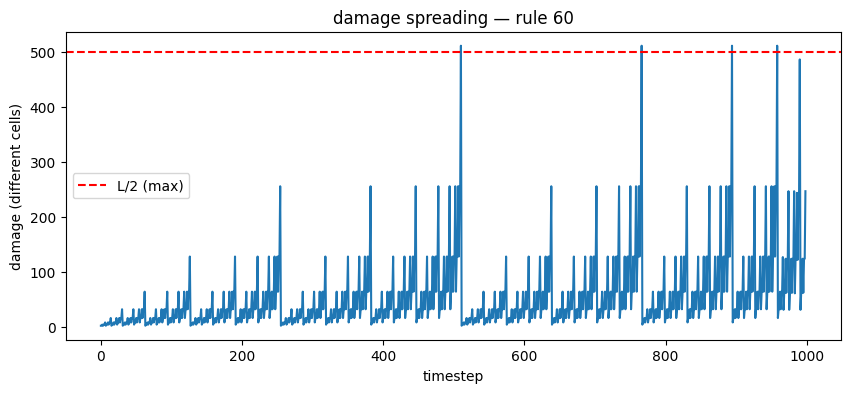

KeyboardInterrupt: 

In [ ]:
def plot_damage(rule):
    dmg = damage(rule)[0]
    plt.figure(figsize=(10, 4))
    plt.plot(dmg)
    plt.axhline(y=500, color='r', linestyle='--', label='L/2 (max)')
    plt.xlabel('timestep')
    plt.ylabel('damage (different cells)')
    plt.title(f'damage spreading — rule {rule}')
    plt.legend()
    plt.show()

plot_damage(60) 
plot_damage(30)

Classifications using lyapunov exponents:
-  λ < 0: The system is increasingly more organized
-  λ > 0: Chaotic or non-trivially structured
- λ ≈ 0: System is relatively uniform and will correspond the organized systems.

### 3.4) Langton's lambda:

Langton, C.G. (1990). "Computation at the Edge of Chaos: Phase Transitions and Emergent Computation." Physica D: Nonlinear Phenomena, 42(1-3), 12-37

Easiest to compute and does not need the dynamics of the system to be calculated.

It takes the binary mapping of the rule and calculates the ratio of combinations that map to one to the total combinations.

In [ ]:
def langtons_lambda(rule):
    rule_bin = format(rule, '08b')
    return sum(int(b) for b in rule_bin) / 8

In this same literature, it is given how this lambda value can be used obtain the class of the respectuve rule, so it doesn't give another method of classifying, but it does give another way to obtain the class of the rule. The classification goes as follows:
- λ = 0.0 Rule 0, class I
- λ = 0.0 - 0.2 Class I
- λ = 0.2 – 0.4 Class II
- λ ~ 0.5 Class IV, at the edge of chaos
- λ = 0.6 – 0.8 Class III
- λ = 0.8 – 1.0 Class I
- λ = 1.0 Class I, all ones

In [ ]:
def classify_by_lambda(rule):
    λ = langtons_lambda(rule)
    
    if λ < 0.2 or λ > 0.8:
        return f"Class I (λ={λ:.3f})"
    elif 0.2 <= λ < 0.4 or 0.6 < λ <= 0.8:
        return f"Class II (λ={λ:.3f})"
    elif 0.45 <= λ <= 0.55:
        return f"Class IV (λ={λ:.3f})"
    else:
        return f"Class III (λ={λ:.3f})"

# Examples
for rule in [0, 4, 30, 110, 255]:
    print(f"Rule {rule} → {classify_by_lambda(rule)}")

print(classify_by_lambda(89))  

Rule 0 → Class I (λ=0.000)
Rule 4 → Class I (λ=0.125)
Rule 30 → Class IV (λ=0.500)
Rule 110 → Class II (λ=0.625)
Rule 255 → Class I (λ=1.000)
Class IV (λ=0.500)


## Summary:
Different ways of classifying cellular automata are studied based on the classifications guven by Stephen Wolfram, classical information theory and the theory of dynamical systems.

- Wolfram's classes: Based on the structures formed throughout the entire dynamics of the system.
- Effective complexity (information theory): Gives a numeric value to how much the past precicts the future non-trivially. Values approaching zero generally correspond to Wolfram's class 0 (trivial evolution) or class III (chaotic evolution). Higher values correspond to class IV (complex, non-trivial sructures) and in between values correspond to class II (less complex structures).
- Lyapunov exponent (dynamical systems): Measures local perturbations over time, it doesn't have a golden rule for mapping the value out to a Wolfram class. However, the common trend is that negative values (disturbance dissappears) correspond to class I, positive values (perturbation increases) corresponds to class III, and class II and IV tend to zero because general strcutures are formed.
- Langton's lambda: Ratio to eight of all binary combinations that map to one within a rule, quite simple parameter and does not exhibit nearly as much information on the systems as the other parameters, but it is computationally cheap. Complex behaviour often occurs near lambda = 0.5.

## 4) Reversibility in elementary cellular automata:
Source: Toffoli & Margolus, Cellular Automata Machines (1987)

### Definition:
A CA is reversisble if you can obtain the current state from the previous state and every state has a bijection (every state has only one predessor).

A CA is irreversible if it has multiple predecessors (convergence) or no predecessors (Garden of Eden states).

### Most rules are irreversible:
Rules typically map many inputs to the same output, so the previous state can't be reconstructed from the current step.

Exampels of reversible rules include trivial transformations like shifts, identity or complements. Examples are the following:
- Rule 15
- Rule 51
- Rule 85
- Rule 170 - Left shift
- Rule 204 - Identity
- Rule 240 - Right shift

### Reversible rules in physics
Reversible CA conserve information perfectly and can be used to model classical physic and also certain parts of quantum mechanics.

All quantum cellular automata are reversible, the initial conditions are a complex vertor and the rule a unitary transformation.

Source: Schumacher & Werner, "Reversible quantum cellular automata", arXiv:quant-ph/0405174 (2004).

-------------

### Function to determine reversibility
We define a function that depicts if a function is reversible or not. A rule will be reversible if the evolution is a bijection, meaning every configuration has exactly one predecessor. 

In the following function, it loops over each initial condition for a lattice of length L creating every single possible initial condition and seeing the subsequent cell, if multiple steps map to the same cell, reversibility is not met. This can only be done for a low length, because the number of possible initial conditions grows non-linearly with L.

In [ ]:
def is_reversible(rule, L=10):
    seen = {}
    
    for i in range(2**L):  # every possible state
        initial = np.array([int(b) for b in format(i, f'0{L}b')])
        row = list(np.where(initial == 1)[0])
        system = dynamics(rule, L, row, 1)
        
        initial_key = tuple(initial)
        final_key   = tuple(system[1, :])
        
        if final_key in seen:
            if seen[final_key] != initial_key:
                return False
        else:
            seen[final_key] = initial_key
    
    return True

In [ ]:
for rule in range(256):
    print(f"rule {rule}: reversible = {is_reversible(rule)}") 

rule 0: reversible = True
rule 1: reversible = True
rule 2: reversible = True
rule 3: reversible = True
rule 4: reversible = True
rule 5: reversible = True
rule 6: reversible = True
rule 7: reversible = True
rule 8: reversible = True
rule 9: reversible = True
rule 10: reversible = True
rule 11: reversible = True
rule 12: reversible = True
rule 13: reversible = True
rule 14: reversible = True
rule 15: reversible = True
rule 16: reversible = True
rule 17: reversible = True
rule 18: reversible = True
rule 19: reversible = True
rule 20: reversible = True
rule 21: reversible = True
rule 22: reversible = True
rule 23: reversible = True
rule 24: reversible = True
rule 25: reversible = True
rule 26: reversible = True
rule 27: reversible = True
rule 28: reversible = True
rule 29: reversible = True
rule 30: reversible = True
rule 31: reversible = True
rule 32: reversible = True
rule 33: reversible = True
rule 34: reversible = True
rule 35: reversible = True
rule 36: reversible = True
rule 37: re

This prints out True for everything which is not the case, this may be due to dynamics inversing the grid, which has given complications in the past. Instead we can define a differnt function that is not depenedent on dynamics, because it is better if dynamics remains untouched as it has proven itself quite useful.

apply_rule is the same as dynamics but for one step and the grid is not reversed.

In [ ]:
def apply_rule(rule, state):
    rule_bin = format(rule, '08b')[::-1]
    L = len(state)
    new_state = np.zeros(L, dtype=int)
    for i in range(L):
        left   = state[i - 1] if i > 0 else 0
        center = state[i]
        right  = state[i + 1] if i < L - 1 else 0
        neighbourhood = left * 4 + center * 2 + right * 1
        new_state[i] = int(rule_bin[neighbourhood])
    return new_state

def is_reversible(rule, L=10):
    seen = {}
    for i in range(2**L):
        initial = np.array([int(b) for b in format(i, f'0{L}b')])
        final = apply_rule(rule, initial)
        initial_key = tuple(initial)
        final_key   = tuple(final)
        if final_key in seen:
            if seen[final_key] != initial_key:
                return False
        else:
            seen[final_key] = initial_key
    return True


In [ ]:
for rule in range(256):
    print(f"rule {rule}: reversible = {is_reversible(rule)}")

# These should print out True:
print("\n")
print(is_reversible(90))
print(is_reversible(150)) #Exactly as predicted

rule 0: reversible = False
rule 1: reversible = False
rule 2: reversible = False
rule 3: reversible = False
rule 4: reversible = False
rule 5: reversible = False
rule 6: reversible = False
rule 7: reversible = False
rule 8: reversible = False
rule 9: reversible = False
rule 10: reversible = False
rule 11: reversible = False
rule 12: reversible = False
rule 13: reversible = False
rule 14: reversible = False
rule 15: reversible = False
rule 16: reversible = False
rule 17: reversible = False
rule 18: reversible = False
rule 19: reversible = False
rule 20: reversible = False
rule 21: reversible = False
rule 22: reversible = False
rule 23: reversible = False
rule 24: reversible = False
rule 25: reversible = False
rule 26: reversible = False
rule 27: reversible = False
rule 28: reversible = False
rule 29: reversible = False
rule 30: reversible = False
rule 31: reversible = False
rule 32: reversible = False
rule 33: reversible = False
rule 34: reversible = False
rule 35: reversible = False
ru

In [ ]:
reversible_CA = []

for i in range(255):
    if is_reversible(i) == True:
        reversible_CA.append(f"Rule {i}")

print(reversible_CA)

['Rule 51', 'Rule 60', 'Rule 90', 'Rule 102', 'Rule 105', 'Rule 150', 'Rule 153', 'Rule 165', 'Rule 195', 'Rule 204']


Important to mention that reversibility depends on lattice size and boundary configuration.

### Garden of Eden 
State that can never be reached through rules, it can only exist in the state as the initial conditions. They depend completely on the rule and each rule will have different gardens as well as a different number of them.

To find the Gardens of Eden, we can fund the number of initial conditions states and have the obtained one step evolutions subtracted from them.

In [ ]:
def gardens_of_eden(rule, L=10):
    all_states = set()
    reachable  = set()

    for i in range(2**L):
        state = tuple(int(b) for b in format(i, f'0{L}b'))
        all_states.add(state)
        next_state = tuple(apply_rule(rule, np.array(state)))
        reachable.add(next_state)

    gardens = all_states - reachable

    print(f"rule {rule}: {len(gardens)} gardens of Eden")
    for g in sorted(gardens):
        print(g)

    return gardens, len(gardens)

gardens_of_eden(0)[1] == gardens_of_eden(255)[1] # This must give true

rule 0: 1023 gardens of Eden
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1)
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0)
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1)
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0)
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1)
(0, 0, 0, 0, 0, 0, 1, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 1, 0, 0, 1)
(0, 0, 0, 0, 0, 0, 1, 0, 1, 0)
(0, 0, 0, 0, 0, 0, 1, 0, 1, 1)
(0, 0, 0, 0, 0, 0, 1, 1, 0, 0)
(0, 0, 0, 0, 0, 0, 1, 1, 0, 1)
(0, 0, 0, 0, 0, 0, 1, 1, 1, 0)
(0, 0, 0, 0, 0, 0, 1, 1, 1, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 1, 0, 0, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 1, 0)
(0, 0, 0, 0, 0, 1, 0, 0, 1, 1)
(0, 0, 0, 0, 0, 1, 0, 1, 0, 0)
(0, 0, 0, 0, 0, 1, 0, 1, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 1, 1, 0)
(0, 0, 0, 0, 0, 1, 0, 1, 1, 1)
(0, 0, 0, 0, 0, 1, 1, 0, 0, 0)
(0, 0, 0, 0, 0, 1, 1, 0, 0, 1)
(0, 0, 0, 0, 0, 1, 1, 0, 1, 0)
(0, 0, 0, 0, 0, 1, 1, 0, 1, 1)
(0, 0, 0, 0, 0, 1, 1, 1, 0, 0)
(0, 0, 0, 0, 0, 1, 1, 1, 0, 1)
(0, 0, 0, 0, 0, 1, 1, 1, 1, 0)
(0, 0, 0, 0, 0, 1, 1, 1, 1, 1)
(0, 0, 0, 

True

In [ ]:
print(gardens_of_eden(239)) # Some arbitrary example

rule 239: 983 gardens of Eden
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1)
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0)
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1)
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0)
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1)
(0, 0, 0, 0, 0, 0, 1, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 1, 0, 0, 1)
(0, 0, 0, 0, 0, 0, 1, 0, 1, 0)
(0, 0, 0, 0, 0, 0, 1, 0, 1, 1)
(0, 0, 0, 0, 0, 0, 1, 1, 0, 0)
(0, 0, 0, 0, 0, 0, 1, 1, 0, 1)
(0, 0, 0, 0, 0, 0, 1, 1, 1, 0)
(0, 0, 0, 0, 0, 0, 1, 1, 1, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 1, 0, 0, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 1, 0)
(0, 0, 0, 0, 0, 1, 0, 0, 1, 1)
(0, 0, 0, 0, 0, 1, 0, 1, 0, 0)
(0, 0, 0, 0, 0, 1, 0, 1, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 1, 1, 0)
(0, 0, 0, 0, 0, 1, 0, 1, 1, 1)
(0, 0, 0, 0, 0, 1, 1, 0, 0, 0)
(0, 0, 0, 0, 0, 1, 1, 0, 0, 1)
(0, 0, 0, 0, 0, 1, 1, 0, 1, 0)
(0, 0, 0, 0, 0, 1, 1, 0, 1, 1)
(0, 0, 0, 0, 0, 1, 1, 1, 0, 0)
(0, 0, 0, 0, 0, 1, 1, 1, 0, 1)
(0, 0, 0, 0, 0, 1, 1, 1, 1, 0)
(0, 0, 0,

# _______

## Summary:
The following was done in this notebook:
- Function to plot multiple grids side by side.
- Created other functions to visually compare systems with one another.
- Function to plot the evolution of one and mutiple cells in different ways
- Found a way to conduct the Fourier analysis of the evolution of cells.
- Distinguished four different ways to classify cellular automata into distinct groups and described how the different classifications were related to one another.
- Studied reversibility of systems, and the concept of bijection and a Garden of Eden State.